#### PsAID-12 Preprocessing & Exploration
October 2024
Patty de Groot

DEPAR PsAID Data 2023  
Data Location Eramus MC > V:\Projecten\Depar\Data\20230301_Data\PsAID12\1-Schone Data  

DEPAR Clinical Data 2023 
Data Location Eramus MC > V:\Projecten\Depar\Data\20230301_Data\20230301_Ziektematen 

THE PSAID12 SCORE: 
Reference: Gossex Ann Rheum Dis 2014 1012-9

PsAID final value=   
(PsAID1 (pain)                 NRS value (range 0–10)×3)+  
(PsAID2 (fatigue)              NRS value (range 0–10)×2)+  
(PsAID3 (skin)                 NRS value (range 0–10)×2)+  
(PsAID4 (Work and/or leisure activities) NRS value (range 0–10)×2)+  
(PsAID5 (function)               NRS value (range 0–10)×2)+  
(PsAID6 (discomfort)            NRS value (range 0–10)×2)+  
(PsAID7 (sleep)               NRS value (range 0–10)×2)+  
(PsAID8 (coping)               NRS value (range 0–10)×1)+  
(PsAID9 (anxiety)               NRS value (range 0–10)×1)+  
(PsAID10 (embarrassment)        NRS value (range 0–10)×1)+  
(PsAID11 (social life)             NRS value (range 0–10)×1)+  
(PsAID12 (depression)            NRS value (range 0–10)×1).  
The total is divided by 20.  

If one of the 12 NRS values composing the PsAID score is missing, the imputation is as follows:  
A. Calculate the mean value of the 11 other (non-missing) > NRS values (range, 0–10)  
B. Impute this value for the missing NRS value  
C. Then, calculate the PsAID score as explained above.  

If 2 or more of the NRS values are missing, the PsAID score is considered a missing value (no imputation)  

## Comments for Change

TO DO: 
- Check the distributions of the clinical variables
- Create table with demographics and disease characteristics included in the 

### Initialization

In [1]:
## Set up
## Import Packages
import warnings
import os

import pandas as pd
import numpy as np
import re # Regular Expressions

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as patches

import seaborn as sns
import plotly.express as px

import sklearn
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score, fowlkes_mallows_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

import scipy
from scipy.spatial.distance import cdist
from scipy.stats import norm, skew, kurtosis, spearmanr, iqr, skewtest, kurtosistest
from scipy.optimize import linear_sum_assignment

# Suppress Future Warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Specify Paths
figure_storage = "/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/Figures"

# Select Random Seed
RandomSeed = 42
print(f'Random seed is set to {RandomSeed}. Cluster algorithms and Neural Networks are optimization algorithms. Therefore the seed affects the initialization and so the model performance.')

Random seed is set to 42. Cluster algorithms and Neural Networks are optimization algorithms. Therefore the seed affects the initialization and so the model performance.


In [2]:
## Import Dataset
psaid12 = pd.read_stata('/Users/pattydegroot/Documents/Python/PsAID12 complete.dta') # Import dataset
psaid12.head() # Check data

# Drop unnessecary variables
columns_gp = [i for i in psaid12.columns if re.match(r'^gp\d{2}$',i)] #Select all columns starting with 'gp' and ending after the 2 digits.
psaid12 = psaid12[['respondentid', 'mm', 'submitdate'] + columns_gp + ['psaid12']]


In [3]:
psaid12

,respondentid,mm,submitdate,gp01,gp02,gp03,gp04,gp05,gp06,gp07,gp08,gp09,gp10,gp11,gp12,psaid12
0,78195329.0,T36,2019-03-31 22:06:01,2,2,2,2,2,Geen<center>0</center>,1,Heel<center>goed</center><center>0</center>,Geen<center>0</center>,Geen<center>0</center>,Geen<center>0</center>,Geen<center>0</center>,1.20
1,10862915.0,T6,2019-02-06 14:26:32,1,6,2,1,1,1,1,1,1,Geen<center>0</center>,Geen<center>0</center>,2,1.55
2,29370588.0,T18,2016-01-06 13:28:33,6,7,5,6,4,6,7,5,6,2,8,5,5.70
3,87648336.0,T18,2016-08-18 00:05:35,Geen<center>0</center>,4,5,Geen<center>0</center>,Geen<center>moeilijkheden</center><center>0</c...,Geen<center>0</center>,Geen<center>probleem</center><center>0</center>,Heel<center>goed</center><center>0</center>,Geen<center>0</center>,1,Geen<center>0</center>,Geen<center>0</center>,0.95
4,42677901.0,T84,2022-04-25 21:30:01,Geen<center>0</center>,Geen<center>vermoeidheid</center><center>0</ce...,Geen<center>0</center>,Geen<center>0</center>,Geen<center>moeilijkheden</center><center>0</c...,Geen<center>0</center>,Geen<center>probleem</center><center>0</center>,Heel<center>goed</center><center>0</center>,Geen<center>0</center>,Geen<center>0</center>,Geen<center>0</center>,Geen<center>0</center>,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5094,48031533.0,Intake ronde,2018-02-28 11:01:09,3,4,1,2,2,3,2,2,1,Geen<center>0</center>,2,1,2.15
5095,71662504.0,T9,2017-02-24 11:31:17,3,3,Geen<center>0</center>,6,6,3,Geen<center>probleem</center><center>0</center>,6,6,Geen<center>0</center>,1,1,2.95
5096,63159202.0,T18,2018-04-05 19:59:43,7,8,Extreem<center>10</center>,8,8,Extreem<center>10</center>,Extreem<center>probleem</center><center>10</ce...,Heel<center>slecht</center><center>10</center>,Extreem<center>10</center>,Extreem<center>10</center>,9,Extreem<center>10</center>,8.90
5097,36477829.0,T36,2020-06-15 10:57:37,7,6,Geen<center>0</center>,6,6,6,6,6,6,4,6,4,5.35


In [4]:
## Create Dictionary

domains_dict = {
    'gp01': 'Pain',
    'gp02': 'Fatigue',
    'gp03': 'Skin',
    'gp04': 'Work-recreational activities',
    'gp05': 'Bodily functioning',
    'gp06': 'Discomfort',
    'gp07': 'Sleep',
    'gp08': 'Coping',
    'gp09': 'Anxiety',
    'gp10': 'Shame',
    'gp11': 'Social activities',
    'gp12': 'Depression'
}

# Create Codebook
print(f' The imported PsAID dataset contains {len(psaid12)} datapoints')
psaid_codebook = pd.DataFrame({
    'Variable' : psaid12.columns.tolist(),
    'Data_type' : psaid12.dtypes.tolist(),
    'Description' : ['Participant', 'Moment of measurement', 'Date of completion', 'Q1 pain', 'Q2 fatigue', 'Q3 skin', 'Q4 work-recreational activities', 'Q5 bodily functioning', 'Q6 discomfort', 'Q7 sleep', 'Q8 coping', 'Q9 anxiety','Q10 shame', 'Q11 social activities', 'Q12 depression', 'PsAID12 Total score'],
    'Exact Question': [ '-',
                        '-',
                        '-',
                        'Kies het getal dat het beste de pijn beschrijft die u voelde als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
                        'Kies het getal dat het beste de mate van vermoeidheid beschrijft die u voelde als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
                        'Kies het getal dat het beste de huidproblemen (inclusief jeuk) beschrijft die u ondervond als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
                        'Kies het getal dat het beste de moeilijkheden beschrijft die u ondervond om volwaardig deel te nemen aan werk- en/of vrije tijdsactiviteiten als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
                        'Kies het getal dat het beste de moeilijkheden met dagelijkse lichamelijke activiteiten beschrijft die u ondervond als gevolg van van uw artritis psoriatica gedurende de afgelopen week.',
                        'Kies het getal dat het beste het gevoel van ongemak en ergernis bij alledaagse activiteiten beschrijft als gevolg van uw artritis psoriatica in de afgelopen week.',
                        'Kies het getal dat het beste de slaapproblemen (bijv. uw nachtrust) beschrijft die u ondervond als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
                        'Kijkend naar uw artritis psoriatica in het algemeen, hoe goed kon u met uw ziekte omgaan gedurende de afgelopen week?',
                        'Kies het getal dat het beste de mate van angst, bezorgdheid en onzekerheid (bijv. over de toekomst, behandelingen, angst voor eenzaamheid) beschrijft die u ondervond als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
                        'Uw artritis psoriatica in het algemeen genomen, kies het getal dat het beste de mate van schaamte beschrijft die u ondervond als gevolg van de zichtbaarheid van uw ziekte gedurende de afgelopen week.',
                        'Kies het getal dat het beste de problemen beschrijft die u had om volledig aan sociale activiteiten deel te nemen (inclusief relaties met familie en vrienden) als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
                        'Kies het getal dat het beste de mate van depressie en/of neerslachtigheid beschrijft die u ondervond als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
                        '-']
})
psaid_codebook 

 The imported PsAID dataset contains 5099 datapoints


,Variable,Data_type,Description,Exact Question
0,respondentid,float64,Participant,-
1,mm,category,Moment of measurement,-
2,submitdate,datetime64[ns],Date of completion,-
3,gp01,category,Q1 pain,Kies het getal dat het beste de pijn beschrijf...
4,gp02,category,Q2 fatigue,Kies het getal dat het beste de mate van vermo...
5,gp03,category,Q3 skin,Kies het getal dat het beste de huidproblemen ...
6,gp04,category,Q4 work-recreational activities,Kies het getal dat het beste de moeilijkheden ...
7,gp05,category,Q5 bodily functioning,Kies het getal dat het beste de moeilijkheden ...
8,gp06,category,Q6 discomfort,Kies het getal dat het beste het gevoel van on...
9,gp07,category,Q7 sleep,Kies het getal dat het beste de slaapproblemen...


In [5]:
np.min(psaid12['submitdate'])

Timestamp('2015-12-01 07:19:29')

In [6]:
## Check data
psaid12.info()
psaid12.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5099 entries, 0 to 5098
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   respondentid  5099 non-null   float64       
 1   mm            5099 non-null   category      
 2   submitdate    5099 non-null   datetime64[ns]
 3   gp01          5099 non-null   category      
 4   gp02          5099 non-null   category      
 5   gp03          5099 non-null   category      
 6   gp04          5099 non-null   category      
 7   gp05          5099 non-null   category      
 8   gp06          5099 non-null   category      
 9   gp07          5099 non-null   category      
 10  gp08          5099 non-null   category      
 11  gp09          5099 non-null   category      
 12  gp10          5099 non-null   category      
 13  gp11          5099 non-null   category      
 14  gp12          5099 non-null   category      
 15  psaid12       5099 non-null   float32 

,respondentid,mm,submitdate,gp01,gp02,gp03,gp04,gp05,gp06,gp07,gp08,gp09,gp10,gp11,gp12,psaid12
0,78195329.0,T36,2019-03-31 22:06:01,2,2,2,2,2,Geen<center>0</center>,1,Heel<center>goed</center><center>0</center>,Geen<center>0</center>,Geen<center>0</center>,Geen<center>0</center>,Geen<center>0</center>,1.20
1,10862915.0,T6,2019-02-06 14:26:32,1,6,2,1,1,1,1,1,1,Geen<center>0</center>,Geen<center>0</center>,2,1.55
2,29370588.0,T18,2016-01-06 13:28:33,6,7,5,6,4,6,7,5,6,2,8,5,5.70
3,87648336.0,T18,2016-08-18 00:05:35,Geen<center>0</center>,4,5,Geen<center>0</center>,Geen<center>moeilijkheden</center><center>0</c...,Geen<center>0</center>,Geen<center>probleem</center><center>0</center>,Heel<center>goed</center><center>0</center>,Geen<center>0</center>,1,Geen<center>0</center>,Geen<center>0</center>,0.95
4,42677901.0,T84,2022-04-25 21:30:01,Geen<center>0</center>,Geen<center>vermoeidheid</center><center>0</ce...,Geen<center>0</center>,Geen<center>0</center>,Geen<center>moeilijkheden</center><center>0</c...,Geen<center>0</center>,Geen<center>probleem</center><center>0</center>,Heel<center>goed</center><center>0</center>,Geen<center>0</center>,Geen<center>0</center>,Geen<center>0</center>,Geen<center>0</center>,0.00


## PREPROCESSING
### Data Formatting

In [7]:
# Format RespondentIDs to integers
psaid12['respondentid'] = psaid12['respondentid'].astype('int')
psaid12.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5099 entries, 0 to 5098
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   respondentid  5099 non-null   int64         
 1   mm            5099 non-null   category      
 2   submitdate    5099 non-null   datetime64[ns]
 3   gp01          5099 non-null   category      
 4   gp02          5099 non-null   category      
 5   gp03          5099 non-null   category      
 6   gp04          5099 non-null   category      
 7   gp05          5099 non-null   category      
 8   gp06          5099 non-null   category      
 9   gp07          5099 non-null   category      
 10  gp08          5099 non-null   category      
 11  gp09          5099 non-null   category      
 12  gp10          5099 non-null   category      
 13  gp11          5099 non-null   category      
 14  gp12          5099 non-null   category      
 15  psaid12       5099 non-null   float32 

In [8]:
# Format MM
# Map categories
mm_categoriesA = ['Intake ronde', 'T3', 'T6', 'T9', 'T12', 'T18', 'T24', 'T36', 'T48', 'T60', 'T72', 'T84', 'T96', 'T108' ] # List of original categories
mm_categoriesB = ['0', '3', '6', '9', '12', '18', '24', '36', '48', '60', '72', '84', '96', '108'] # List of new categories
psaid12['mm'] = psaid12['mm'].replace(dict(zip(mm_categoriesA ,mm_categoriesB))) #replace original with new categories

# Convert objects to integers
psaid12['mm'] = psaid12['mm'].astype('int')
assert psaid12['mm'].dtype == 'int' #Check if the mm are indeed integers

unique_values_mm = sorted(psaid12['mm'].unique())
print(unique_values_mm) #check if replaced
psaid12['mm'].info()

[0, 3, 6, 9, 12, 18, 24, 36, 48, 60, 72, 84, 96, 108]
<class 'pandas.core.series.Series'>
RangeIndex: 5099 entries, 0 to 5098
Series name: mm
Non-Null Count  Dtype
--------------  -----
5099 non-null   int64
dtypes: int64(1)
memory usage: 40.0 KB


In [9]:
### Correct gp data
# Convert from category to object so we can make changes
psaid12[columns_gp] = psaid12[columns_gp].astype('object')
for col in columns_gp:
    assert (psaid12[col].dtype) == 'object' # Assure if datatype is changed

# Check which Answer options are present in the dataframe
# Run when new data is uploaded
# summary_table_gp = pd.DataFrame({'gp01': psaid12['gp01'].value_counts(),
#                                  'gp02': psaid12['gp02'].value_counts(),
#                                  'gp03': psaid12['gp03'].value_counts(),
#                                  'gp04': psaid12['gp04'].value_counts(),
#                                  'gp05': psaid12['gp05'].value_counts(),
#                                  'gp06': psaid12['gp06'].value_counts(),
#                                  'gp07': psaid12['gp07'].value_counts(),
#                                  'gp08': psaid12['gp08'].value_counts(),
#                                  'gp09': psaid12['gp09'].value_counts(),
#                                  'gp10': psaid12['gp10'].value_counts(),
#                                  'gp11': psaid12['gp11'].value_counts(),
#                                  'gp12': psaid12['gp12'].value_counts()
#                                 })
# print(summary_table_gp)

# Map answer categories
# Mapping is based on the PSAID12 questionnaire answers, see PDF [PsAID12_vragenlijst.pdf].
# 0 = good, 10 = bad
gp_categoriesA = ['Extreem<center>10</center> ', 'Geen<center>probleem</center><center>0</center> ', 'Volledig<center>uitgeput</center><center>10</center> ',  'Geen<center>vermoeidheid</center><center>0</center> ', 'Extreem<center>probleem</center><center>10</center> ', 'Geen<center>0</center> ', 'Geen<center>moeilijkheden</center><center>0</center> ', 'Heel<center>goed</center><center>0</center> ', 'Extreem<center>10</center>', 'Geen<center>probleem</center><center>0</center> ', 'Extreme<center>moeilijkheden</center><center>10</center> ', 'Heel<center>slecht</center><center>10</center> '] 
gp_categoriesB = ['10', '0','10','0', '10', '0', '0', '0', '10', '0', '10', '10'] #New category names

# Replace odd answers
psaid12 = psaid12.replace(dict(zip(gp_categoriesA, gp_categoriesB))) #Replace old with new category names
unique_values_gp = set(psaid12.loc[:,['gp' in col for col in psaid12.columns]].values.ravel()) #Create set of unique categorical values in all gp variables
print(unique_values_gp) 

# Convert gp answers to numeric datatype
psaid12[columns_gp] = psaid12[columns_gp].apply(pd.to_numeric).astype(int) # Convert selection to to numeric datatypes

for col in columns_gp:
    assert (psaid12[col].dtype) == 'int' # Assure if datatype is changed
    assert (psaid12[col] >= 0 ).all(), "Values smaller than 0" #Check that the values range between 0-10
    assert (psaid12[col] <= 10).all(), "Values exceed 10" #Check that the values range between 0-10 

psaid12.head()
psaid12.info() # Check if gp columns are converted from category > numeric


{'3', '10', '1', '9', '2', '5', '8', '6', '4', '7', '0'}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5099 entries, 0 to 5098
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   respondentid  5099 non-null   int64         
 1   mm            5099 non-null   int64         
 2   submitdate    5099 non-null   datetime64[ns]
 3   gp01          5099 non-null   int64         
 4   gp02          5099 non-null   int64         
 5   gp03          5099 non-null   int64         
 6   gp04          5099 non-null   int64         
 7   gp05          5099 non-null   int64         
 8   gp06          5099 non-null   int64         
 9   gp07          5099 non-null   int64         
 10  gp08          5099 non-null   int64         
 11  gp09          5099 non-null   int64         
 12  gp10          5099 non-null   int64         
 13  gp11          5099 non-null   int64         
 14  gp12          5099 non-null   i

### Normalization - NA
No normalization necessary since all parameters are already on the same scale

In [10]:
psaid12.head()

,respondentid,mm,submitdate,gp01,gp02,gp03,gp04,gp05,gp06,gp07,gp08,gp09,gp10,gp11,gp12,psaid12
0,78195329,36,2019-03-31 22:06:01,2,2,2,2,2,0,1,0,0,0,0,0,1.20
1,10862915,6,2019-02-06 14:26:32,1,6,2,1,1,1,1,1,1,0,0,2,1.55
2,29370588,18,2016-01-06 13:28:33,6,7,5,6,4,6,7,5,6,2,8,5,5.70
3,87648336,18,2016-08-18 00:05:35,0,4,5,0,0,0,0,0,0,1,0,0,0.95
4,42677901,84,2022-04-25 21:30:01,0,0,0,0,0,0,0,0,0,0,0,0,0.00


### Save Formatted Dataset

In [11]:
folder_path = "/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_Pre-Processing & Inspection"
file_name = "PsAID_Preprocessed"

# Ensure the folder exists
os.makedirs(folder_path, exist_ok=True)

# Save
psaid12.to_csv(f'{folder_path}/{file_name}.csv', index=False)
print(f' Dataset saved to {folder_path}/{file_name}.csv')

 Dataset saved to /Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_Pre-Processing & Inspection/PsAID_Preprocessed.csv


## Data Inspection

#### Duplicates - None

In [12]:
## Check for Duplicates
duplicates = psaid12.duplicated(subset=['respondentid','mm'], keep = False) #Create boolean list with duplicate = True)
print(f"There are {len(psaid12[duplicates].groupby(['respondentid','mm']).size())} respondents with duplicate data")

There are 0 respondents with duplicate data


### Outliers - NA 
Categorical values so no outliers possible

### Score Distributions

,gp01,gp02,gp03,gp04,gp05,gp06,gp07,gp08,gp09,gp10,gp11,gp12,psaid12
count,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.00000
mean,3.498725,3.693665,2.342028,2.696019,2.851736,2.918611,2.660522,2.341439,2.100020,1.132183,1.769563,1.461855,2.68132
std,2.739678,3.006385,2.546912,2.792231,2.693945,2.739623,2.940543,2.647180,2.655704,2.117799,2.517270,2.393815,2.24122
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.70000
50%,3.000000,3.000000,1.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.15000
75%,6.000000,6.000000,4.000000,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000,1.000000,3.000000,2.000000,4.35000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000


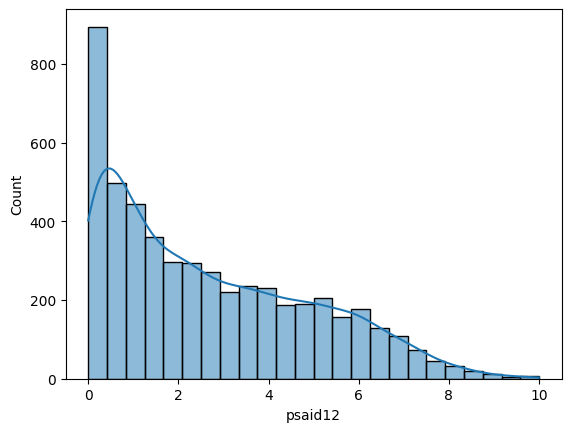

In [14]:
## Check PsAID12 scores 
# Data Distribution
sns.histplot(psaid12['psaid12'], kde=True)
#fig.suptitle("PsAID Data Distribution Total Score", fontsize=20)
plt.savefig(os.path.join(figure_storage, 'PsAID_DataDistribution_TotalScore.png'))
plt.show

psaid12[columns_gp + ['psaid12']].describe()

#### Distributions per Timepoint

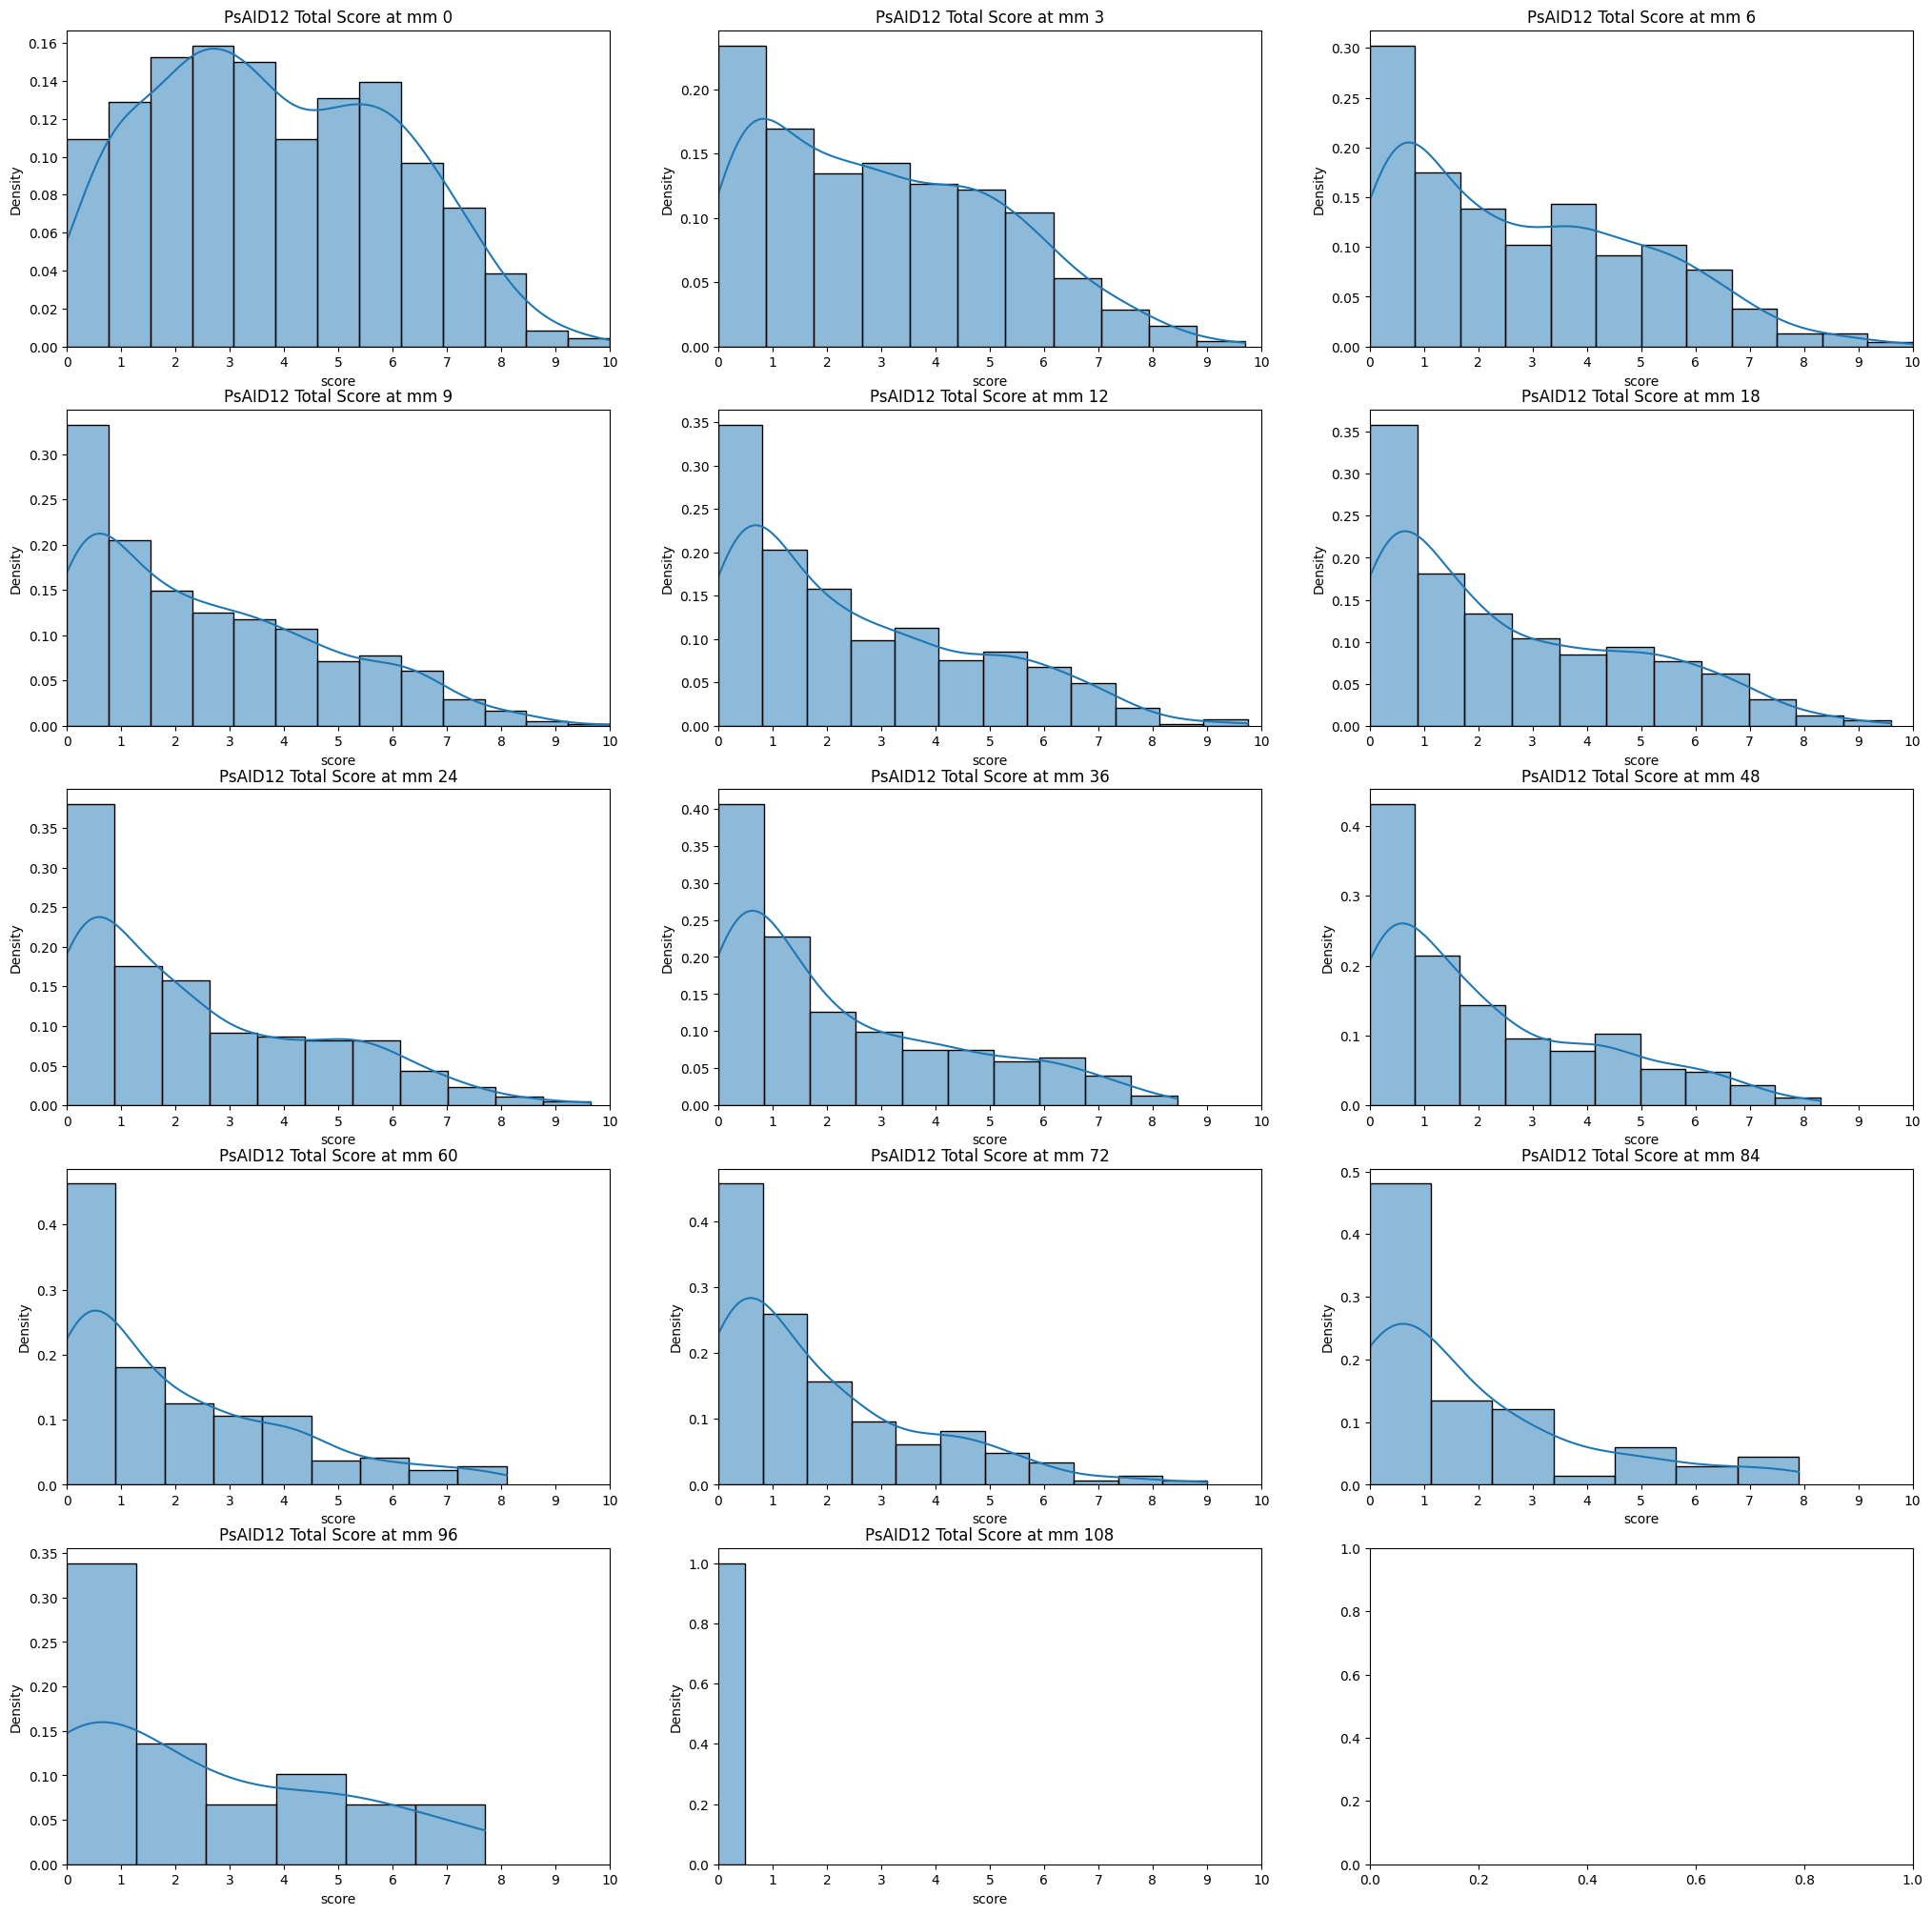

In [15]:
 ## Check PsAID12 score Distribution per timepoint
def plot_histograms_byvals(data, score, byval, title):
    """
    Function that creates figures which splits the data by the values of a certain variable and creates a histogram for each category.
    """

    unique_val = sorted(data[byval].unique())

    #Initialize Figure
    fig, axes = plt.subplots(ncols=3, nrows=round(np.ceil(len(unique_val)/3)), figsize=(25,25)) #Set up a figure grid of subplots
    axes = axes.flatten() #Number subplots, ignore colums

    # Plot histogram with density for each variable
    for i, t in enumerate(unique_val): #Loop over mm
        subset = data[data[byval]==t]
        sns.histplot(subset[score], kde=True, ax=axes[i], label = t, stat='density')
        #Format plots
        axes[i].set_title(f'{title} {t}')
        axes[i].set_ylabel('Density')
        axes[i].set_xlabel('score')
        axes[i].set_xlim(0,10)
        axes[i].set_xticks(np.arange(0,11,1))

 plot_histograms_byvals(psaid12, 'psaid12', 'mm', 'PsAID12 Total Score at mm')

In [16]:
# Ensure the folder exists
os.makedirs('data_storage', exist_ok=True)

# Function to compute median [Q1, Q3]
def median_iqr(series):
    q1 = series.quantile(0.25)
    median = series.quantile(0.5)
    q3 = series.quantile(0.75)
    return f"{median:.2f} [{q1:.2f}, {q3:.2f}]"

# Counts per group (once)
counts = psaid12.groupby('mm').size().rename('n')

# Median [Q1, Q3] for domains
medians_iqr_domains = psaid12.groupby('mm')[columns_gp].agg(median_iqr)

# Median [Q1, Q3] for total PsAID-12 score
medians_iqr_total = psaid12.groupby('mm')['psaid12'].agg(median_iqr).rename('PsAID-12 total')

# Replace domain column names with descriptive names
columns_named = [domains_dict.get(col, col) for col in columns_gp]
medians_iqr_domains.columns = columns_named

# Combine counts, domain medians, and total score
summary_table = pd.concat([counts, medians_iqr_domains, medians_iqr_total], axis=1)

# Save to Excel
summary_table.to_excel('data_storage/psaid12_summary.xlsx', index=True)

print("Summary table saved to data_storage/psaid12_summary.xlsx")


Summary table saved to data_storage/psaid12_summary.xlsx


#### Distributions by domain

In [62]:
summary_table

,n,Pain,Fatigue,Skin,Work-recreational activities,Bodily functioning,Discomfort,Sleep,Coping,Anxiety,Shame,Social activities,Depression,PsAID-12 total
mm,,,,,,,,,,,,,,
0,606,"6.00 [3.00, 7.00]","5.00 [2.00, 7.00]","3.00 [1.00, 6.00]","4.00 [1.00, 6.00]","4.00 [2.00, 7.00]","4.50 [2.00, 7.00]","3.00 [0.00, 7.00]","3.00 [1.00, 5.00]","3.00 [0.00, 6.00]","0.00 [0.00, 3.00]","1.00 [0.00, 5.00]","1.00 [0.00, 3.00]","3.60 [2.10, 5.60]"
3,557,"4.00 [2.00, 6.00]","4.00 [1.00, 7.00]","2.00 [1.00, 4.00]","3.00 [0.00, 5.00]","3.00 [1.00, 6.00]","3.00 [1.00, 6.00]","2.00 [0.00, 5.00]","2.00 [0.00, 5.00]","2.00 [0.00, 4.00]","0.00 [0.00, 2.00]","1.00 [0.00, 4.00]","0.00 [0.00, 3.00]","2.80 [1.05, 4.70]"
6,563,"3.00 [1.00, 6.00]","4.00 [1.00, 7.00]","2.00 [0.00, 4.00]","2.00 [0.00, 5.00]","3.00 [0.00, 5.00]","2.00 [1.00, 5.00]","2.00 [0.00, 5.00]","2.00 [0.00, 5.00]","1.00 [0.00, 4.00]","0.00 [0.00, 2.00]","1.00 [0.00, 3.00]","0.00 [0.00, 2.00]","2.35 [0.80, 4.50]"
9,532,"3.00 [1.00, 6.00]","3.00 [1.00, 7.00]","1.00 [0.00, 4.00]","2.00 [0.00, 5.00]","2.00 [0.00, 5.00]","2.00 [0.00, 5.00]","1.00 [0.00, 5.00]","1.00 [0.00, 4.00]","1.00 [0.00, 3.25]","0.00 [0.00, 1.00]","0.00 [0.00, 3.00]","0.00 [0.00, 2.00]","2.15 [0.74, 4.11]"
12,521,"3.00 [1.00, 6.00]","3.00 [1.00, 7.00]","1.00 [0.00, 4.00]","2.00 [0.00, 5.00]","2.00 [0.00, 5.00]","2.00 [0.00, 5.00]","1.00 [0.00, 5.00]","1.00 [0.00, 3.00]","1.00 [0.00, 3.00]","0.00 [0.00, 1.00]","0.00 [0.00, 3.00]","0.00 [0.00, 2.00]","1.95 [0.70, 4.10]"
18,550,"3.00 [1.00, 6.00]","3.00 [1.00, 7.00]","1.00 [0.00, 4.00]","2.00 [0.00, 5.00]","2.00 [0.00, 5.00]","2.00 [0.00, 5.00]","1.00 [0.00, 5.00]","1.00 [0.00, 4.00]","1.00 [0.00, 3.00]","0.00 [0.00, 1.00]","0.00 [0.00, 3.00]","0.00 [0.00, 2.00]","1.88 [0.60, 4.34]"
24,498,"2.00 [1.00, 5.00]","3.00 [1.00, 6.00]","1.00 [0.00, 3.00]","1.00 [0.00, 5.00]","2.00 [0.00, 5.00]","2.00 [0.00, 5.00]","1.00 [0.00, 4.00]","1.00 [0.00, 3.00]","1.00 [0.00, 3.00]","0.00 [0.00, 1.00]","0.00 [0.00, 2.00]","0.00 [0.00, 2.00]","1.85 [0.55, 4.04]"
36,443,"2.00 [1.00, 5.00]","3.00 [1.00, 6.00]","1.00 [0.00, 3.00]","1.00 [0.00, 4.00]","1.00 [0.00, 4.00]","1.00 [0.00, 4.00]","1.00 [0.00, 5.00]","1.00 [0.00, 3.00]","0.00 [0.00, 2.00]","0.00 [0.00, 1.00]","0.00 [0.00, 2.00]","0.00 [0.00, 2.00]","1.55 [0.50, 3.75]"
48,327,"2.00 [1.00, 5.00]","2.00 [0.50, 6.00]","1.00 [0.00, 3.00]","1.00 [0.00, 4.00]","2.00 [0.00, 4.00]","1.00 [0.00, 4.00]","1.00 [0.00, 4.00]","1.00 [0.00, 3.00]","0.00 [0.00, 2.00]","0.00 [0.00, 1.00]","0.00 [0.00, 2.00]","0.00 [0.00, 1.00]","1.55 [0.50, 3.52]"


 gp01: min, -0.5 max, 10.5
10.55
 gp02: min, -0.5 max, 10.5
10.55
 gp03: min, -0.5 max, 10.5
10.55
 gp04: min, -0.5 max, 10.5
10.55
 gp05: min, -0.5 max, 10.5
10.55
 gp06: min, -0.5 max, 10.5
10.55
 gp07: min, -0.5 max, 10.5
10.55
 gp08: min, -0.5 max, 10.5
10.55
 gp09: min, -0.5 max, 10.5
10.55
 gp10: min, -0.5 max, 10.5
10.55
 gp11: min, -0.5 max, 10.5
10.55
 gp12: min, -0.5 max, 10.5
10.55


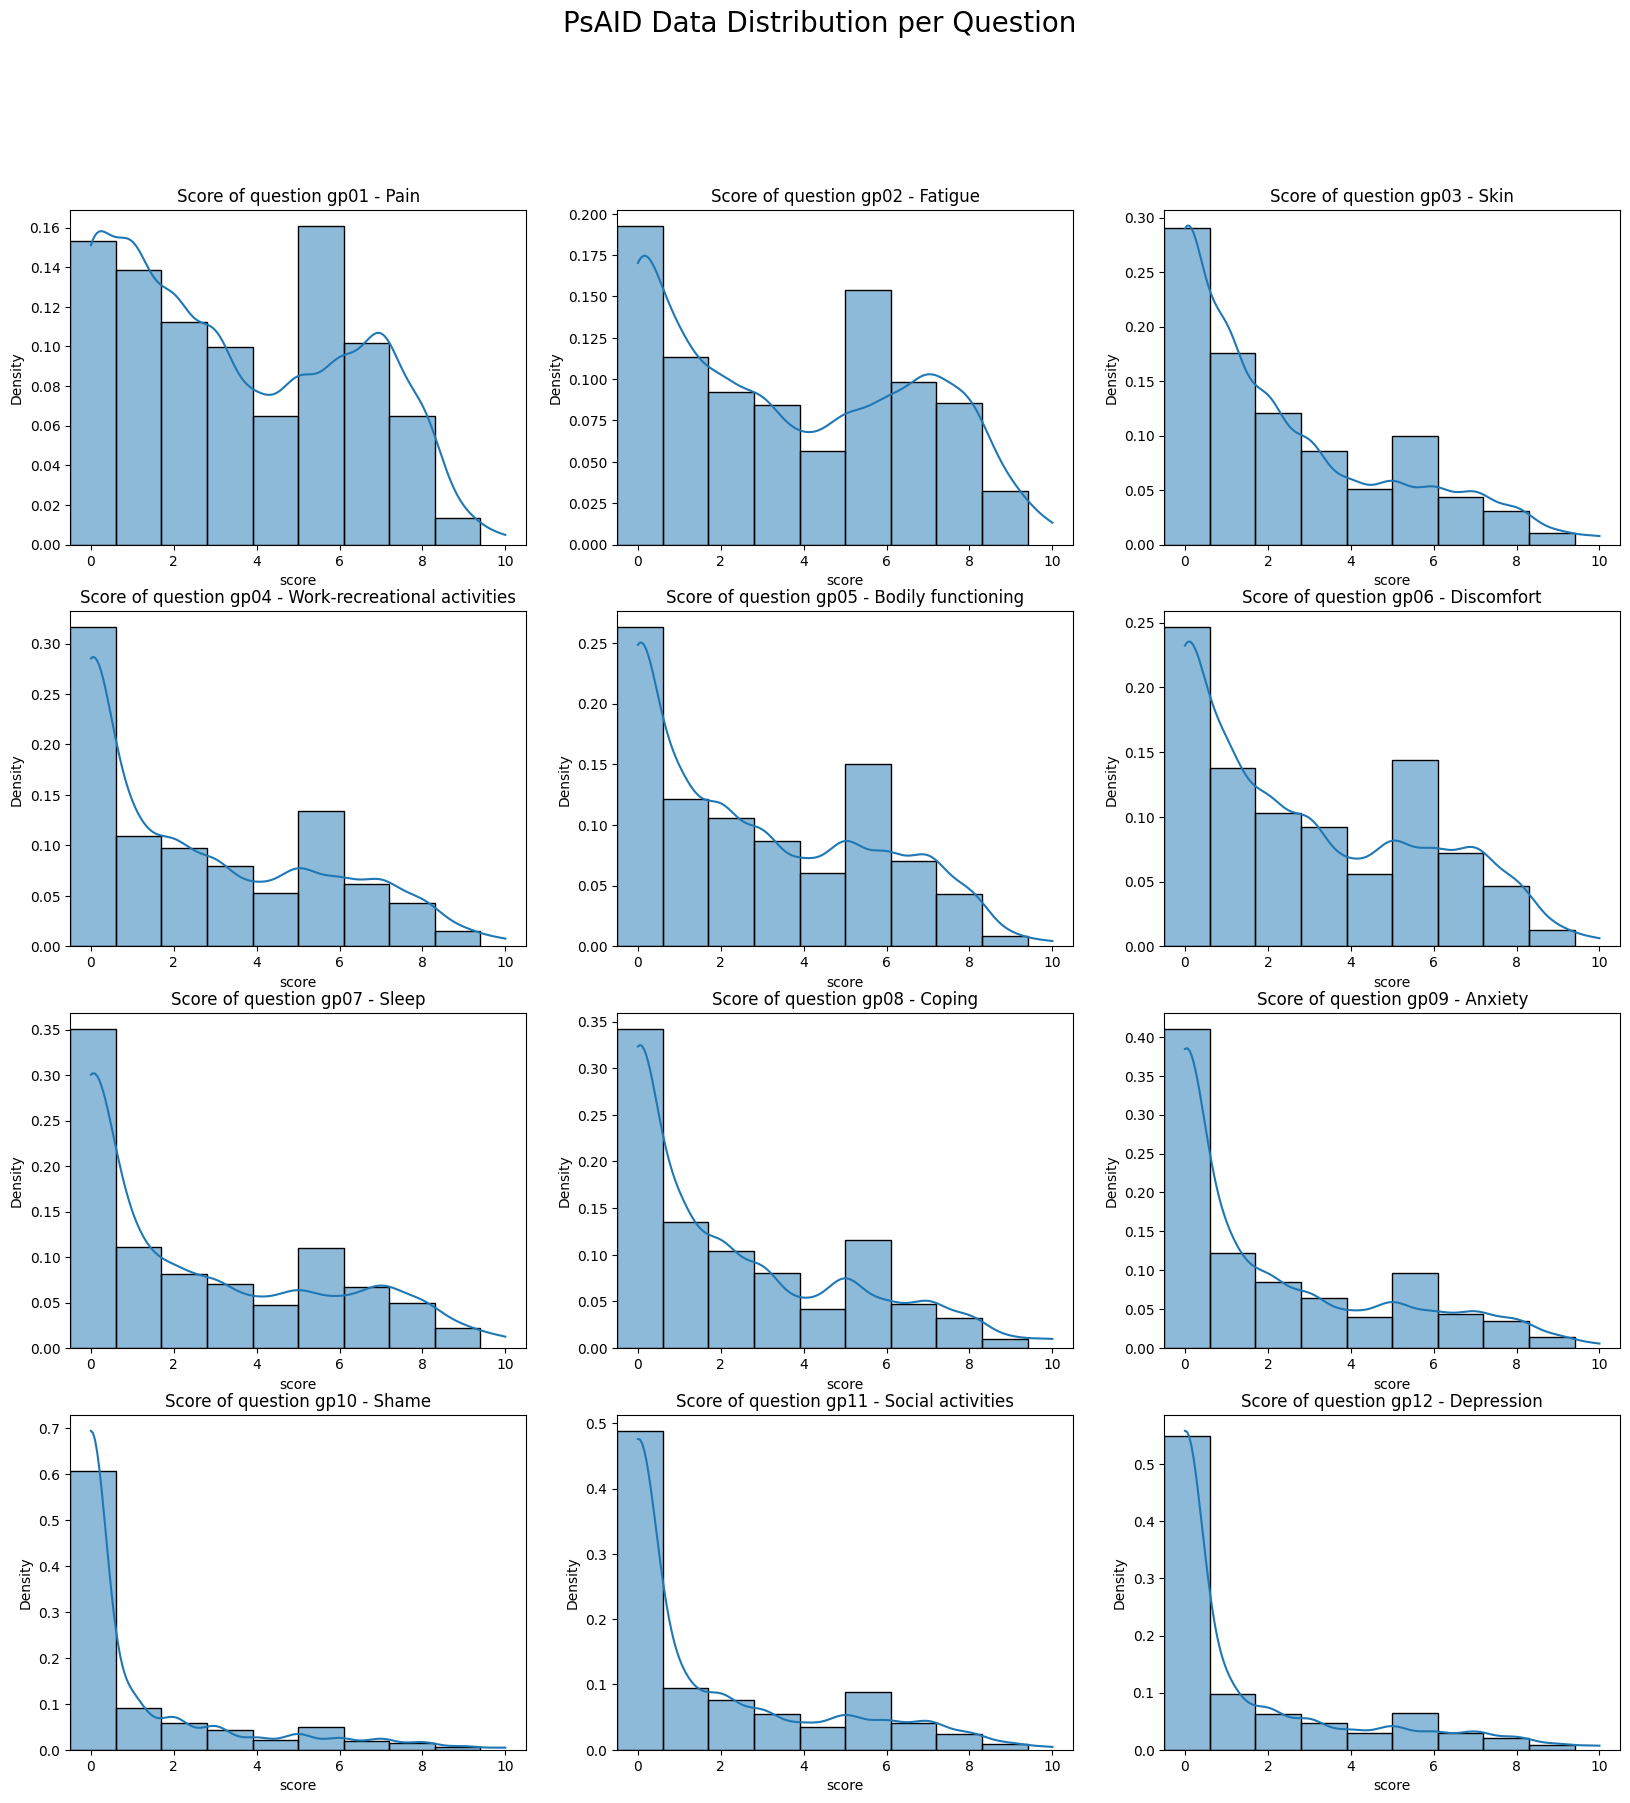

In [17]:
## Check data distribution for each question
import math
def plot_histograms_byvars(data, varlist, dictionary, title):
    """
    Function that creates figures which show the value distribution of multiple variables
    """

    #Initialize Figure
    fig, axes = plt.subplots(ncols=3, nrows=round(np.ceil(len(varlist)/3)), figsize=(20,20)) #Set up a figure grid of subplots
    axes = axes.flatten() #Number subplots, ignore colums

    # Plot histogram with density for each variable
    for i, col in enumerate(varlist): #Loop over variables
        #Determine Limits
        minx = np.copysign(math.ceil(np.abs(data[[col]].min().min())), data[varlist].min().min())-0.5
        maxx = np.copysign(math.ceil(np.abs(data[[col]].max().max())), data[varlist].max().max())+0.5
        print(f' {col}: min, {minx} max, {maxx}')
        print(maxx-minx/10)

        
        bins= np.arange(minx, maxx, (maxx-minx)/10)
        sns.histplot(data[col], kde=True, ax=axes[i], stat='density', bins=bins)

        #Format plots
        axes[i].set_title(f'Score of question {col} - {dictionary[col]}')
        axes[i].set_ylabel('Density')
        axes[i].set_xlabel('score')
        axes[i].set_xlim(minx, maxx)
        #axes[i].set_ylim(0,0.7)
        #axes[i].set_xticks(np.arange(0, 11, 1))
       # axes[i].set_xticklabels(np.arange(0, 11, 1))

    fig.suptitle(f'{title}', fontsize=20)
    plt.savefig(os.path.join(figure_storage, f'{title}.png'))
    plt.show()

    """
    How can I align the numbers at the middle of the bars? Use Barplot instead?
    """

plot_histograms_byvars(psaid12, columns_gp, domains_dict, 'PsAID Data Distribution per Question')

#### Violin Plot

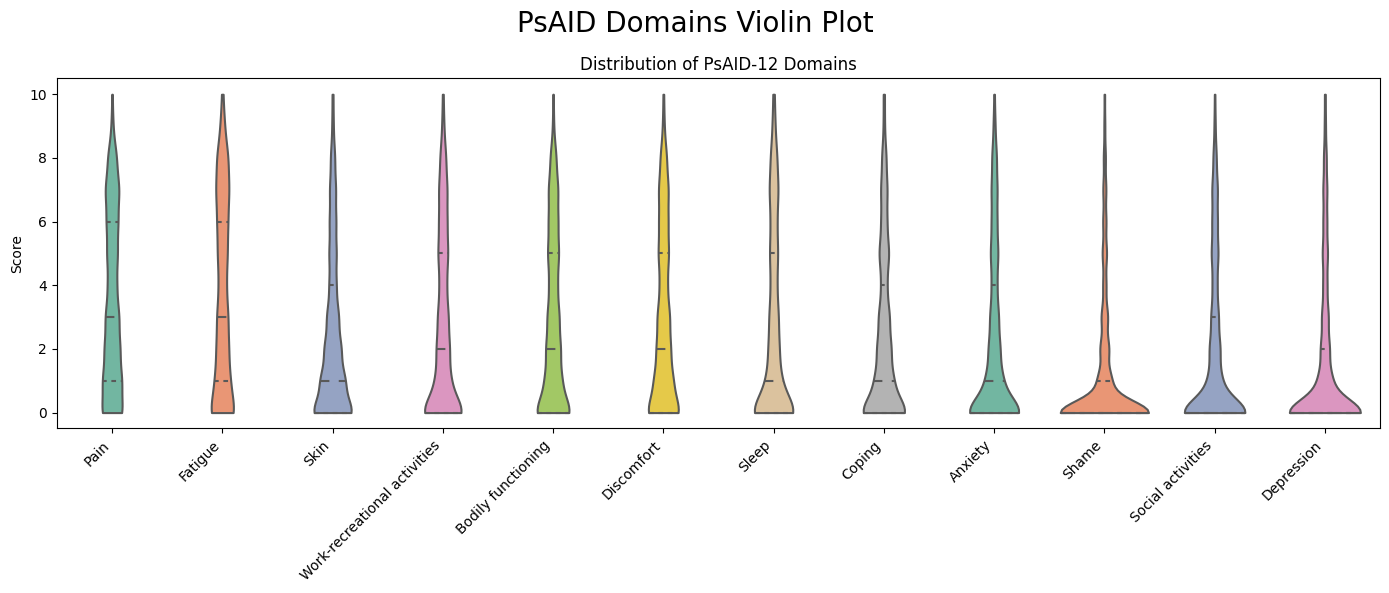

In [18]:
# Melt the DataFrame to long format for seaborn
psaid_long = psaid12.melt(value_vars=columns_gp,
                          var_name='Domain', value_name='Score')

# Map gp codes to descriptive domain names
psaid_long['Domain'] = psaid_long['Domain'].map(domains_dict)

# Create violin plot
plt.figure(figsize=(14,6))
sns.violinplot(x='Domain', y='Score', data=psaid_long, inner='quartile', palette="Set2", cut=0)
plt.title("Distribution of PsAID-12 Domains")
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=45, ha='right')

title = 'PsAID Domains Violin Plot'
plt.suptitle(f'{title}', fontsize=20)
plt.tight_layout()
plt.savefig(os.path.join(figure_storage, f'{title}.png'))
plt.show()


In [19]:
# Standard Scaled data
#tSNE_2D(data_StandardScaled, columns_gp, RandomSeed)

#### Skewness & Kurtosis

In [20]:
SK2_results = []

for col in columns_gp:
    x = psaid12[col].dropna()
    skew_stat, skew_p = skewtest(x)
    kurt_stat, kurt_p = kurtosistest(x)

    SK2_results.append({
        "Variable": col,
        "Skewness": skew(x),
        "Skewness p": skew_p,
        "Kurtosis": kurtosis(x),
        "Kurtosis p": kurt_p
    })

sk_kurt_df = pd.DataFrame(SK2_results)
print(sk_kurt_df)


   Variable  Skewness     Skewness p  Kurtosis     Kurtosis p
0      gp01  0.316856   1.660237e-19 -1.185289   0.000000e+00
1      gp02  0.265433   2.548801e-14 -1.286783   0.000000e+00
2      gp03  1.043757  2.197234e-142  0.081510   2.318258e-01
3      gp04  0.716329   1.542860e-79 -0.741265   9.921486e-73
4      gp05  0.577812   1.259026e-55 -0.914475  4.329600e-164
5      gp06  0.600843   1.984340e-59 -0.880042  5.628596e-139
6      gp07  0.797393   1.756233e-94 -0.691878   7.347172e-58
7      gp08  0.988670  1.853685e-131 -0.111761   9.331074e-02
8      gp09  1.123380  2.715094e-158  0.053088   4.197934e-01
9      gp10  2.097981   0.000000e+00  3.687112   1.047038e-97
10     gp11  1.319801  9.679274e-198  0.560339   7.737851e-11
11     gp12  1.701603  2.531639e-273  1.908860   2.985209e-51


In [21]:
sk_results = []

for col in columns_gp:
    x = psaid12[col].dropna()
    
    # Effect sizes
    sk = skew(x)
    ku = kurtosis(x)  # Fisher definition: normal == 0
    
    # Significance tests
    sk_stat, sk_p = skewtest(x)
    ku_stat, ku_p = kurtosistest(x)
    
    # Flag based on effect size thresholds
    flag_parts = []
    if abs(sk) > 1:
        flag_parts.append("HIGH SKEW")
    if ku > 3:
        flag_parts.append("HIGH KURT")
    flag = " | ".join(flag_parts) if flag_parts else ""
    
    # Store results
    sk_results.append({
        "Variable": col,
        "Skewness": sk,
        "Skewness p-value": sk_p,
        "Kurtosis": ku,
        "Kurtosis p-value": ku_p,
        "Flag": flag
    })

flag_df = pd.DataFrame(sk_results)
flag_df

,Variable,Skewness,Skewness p-value,Kurtosis,Kurtosis p-value,Flag
0,gp01,0.316856,1.660237e-19,-1.185289,0.000000e+00,
1,gp02,0.265433,2.548801e-14,-1.286783,0.000000e+00,
2,gp03,1.043757,2.197234e-142,0.081510,2.318258e-01,HIGH SKEW
3,gp04,0.716329,1.542860e-79,-0.741265,9.921486e-73,
4,gp05,0.577812,1.259026e-55,-0.914475,4.329600e-164,
5,gp06,0.600843,1.984340e-59,-0.880042,5.628596e-139,
6,gp07,0.797393,1.756233e-94,-0.691878,7.347172e-58,
7,gp08,0.988670,1.853685e-131,-0.111761,9.331074e-02,
8,gp09,1.123380,2.715094e-158,0.053088,4.197934e-01,HIGH SKEW
9,gp10,2.097981,0.000000e+00,3.687112,1.047038e-97,HIGH SKEW | HIGH KURT


#### PCA

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def PCA_plot(data, varlist):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(data[varlist])
    
    plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
    plt.title('PCA Projection (2D)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()

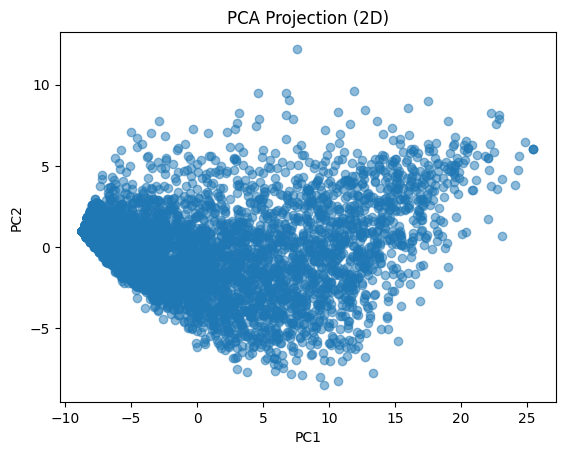

In [23]:
PCA_plot(psaid12, columns_gp)

In [24]:
#PCA_plot(data_RobustScaled, columns_gp)

In [25]:
#PCA_plot(data_StandardScaled, columns_gp)

### KDE Pairplot - Disabled 
Disabled for computation purposes. Takes much time.

In [26]:
## Create Pairplot
pp = sns.pairplot(psaid12[columns_gp], corner=True, diag_kind='kde', plot_kws={"color": "mistyrose"})
pp.map_lower(sns.kdeplot, levels = 8, shade=True, cmap="Reds") #Add filled contours
pp.map_lower(sns.kdeplot, levels=8, color="darkred", linewidths=0.2) # Add contour lines

# Format axes
for i, j in zip(*np.tril_indices_from(pp.axes, k=-1)):  # Loop only through the lower triangle
     if pp.axes[i, j] is not None:
        pp.axes[i, j].set_xlabel(domains_dict[columns_gp[j]], fontsize=12)
        pp.axes[i, j].set_ylabel(domains_dict[columns_gp[i]], fontsize=12)
        pp.axes[i, j].set(xlim=(0,10), ylim = (0,10))
         
fig.suptitle("PsAID Data Distribution Heatmap", fontsize=20)
plt.savefig(os.path.join(figure_storage, 'PsAID_DataDistribution_Heatmap.png'))
plt.show

### Spearman's Rank-Correlation Matrix 

Our data is: 
* Continuous on the same scale of 0-10
* Not normally distributed
* Zero-inflated - Structural zeros (represent the true absence of the phenomenon 'no symptom')

Correlations:

* Pearson Correlation: 
> * When your data is continuous and you assume a linear relationship between variables.
> * Variables should be normally distributed (though it is somewhat robust to deviations from normality).

* Spearman Rank Correlation: 
> * Your data is continuous or ordinal, and you don't assume linearity.
> * Suitable for non-normally distributed data.

* Kendall Tau Correlation:
> * Similar to Spearman but works better for small sample sizes or data with many tied ranks.
> * No requirements, measures ordinal association.

Spearman Rank Correlations: 
                    gp01               gp02               gp03  \
gp01  1.00 (p=0.000)***  0.74 (p=0.000)***  0.41 (p=0.000)***   
gp02  0.74 (p=0.000)***  1.00 (p=0.000)***  0.39 (p=0.000)***   
gp03  0.41 (p=0.000)***  0.39 (p=0.000)***  1.00 (p=0.000)***   
gp04  0.75 (p=0.000)***  0.77 (p=0.000)***  0.40 (p=0.000)***   
gp05  0.81 (p=0.000)***  0.78 (p=0.000)***  0.41 (p=0.000)***   
gp06  0.78 (p=0.000)***  0.75 (p=0.000)***  0.45 (p=0.000)***   
gp07  0.66 (p=0.000)***  0.69 (p=0.000)***  0.39 (p=0.000)***   
gp08  0.71 (p=0.000)***  0.71 (p=0.000)***  0.43 (p=0.000)***   
gp09  0.60 (p=0.000)***  0.61 (p=0.000)***  0.41 (p=0.000)***   
gp10  0.43 (p=0.000)***  0.44 (p=0.000)***  0.51 (p=0.000)***   
gp11  0.61 (p=0.000)***  0.68 (p=0.000)***  0.39 (p=0.000)***   
gp12  0.50 (p=0.000)***  0.59 (p=0.000)***  0.37 (p=0.000)***   

                   gp04               gp05               gp06  \
gp01  0.75 (p=0.000)***  0.81 (p=0.000)***  0.78 (p=0.000)*

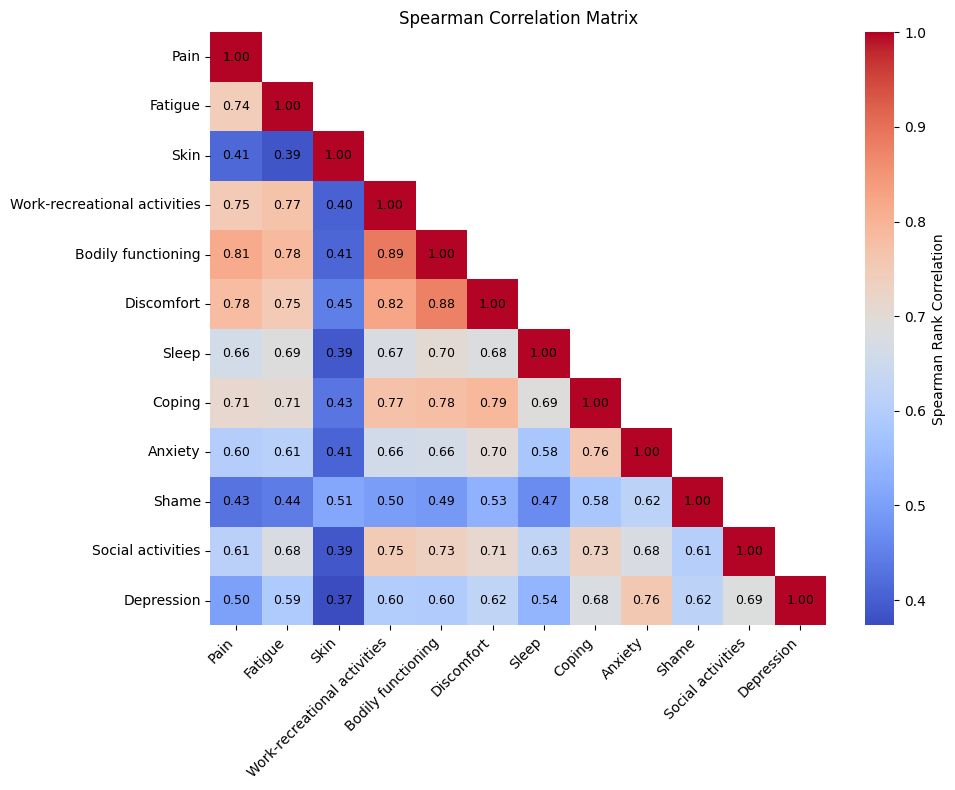

In [27]:
## Compute Spearman's Rank-Correlation
correlation_matrix, p_values_matrix = spearmanr(psaid12[columns_gp])

## Table with correlations and p-values
# Convert matrices to DataFrames
correlation_df = pd.DataFrame(correlation_matrix, columns=columns_gp, index=columns_gp)
p_values_df = pd.DataFrame(p_values_matrix, columns=columns_gp, index=columns_gp)
combined_df = correlation_df.copy()

# Format Significance values
def significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

# Format the combined table to show both correlation and p-value
for i in range(len(combined_df)):
    for j in range(len(combined_df.columns)):
        r = correlation_df.iloc[i,j]
        p = p_values_df.iloc[i,j]
        stars = significance_stars(p)
        combined_df.iloc[i, j] = f"{r:.2f} (p={p:.3f}){stars}"

# Display the formatted table
print(f'Spearman Rank Correlations: \n {combined_df} \n\n All correlations are significant p<0.05 \n')


## Visualise correlations with Heatmap
plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt='.2f', 
            mask=mask, cbar_kws={'label': 'Spearman Rank Correlation'}, 
            xticklabels=[domains_dict[col] for col in columns_gp], 
            yticklabels=[domains_dict[col] for col in columns_gp])

plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels by 45 degrees

# Add values to the heatmap
for i in range(len(correlation_matrix)):
    for j in range(i + 1):  # Including diagonal (i == j)
        stars = significance_stars(p_values_matrix[i,j])
        plt.text(j + 0.5, i + 0.5, f"{correlation_matrix[i, j]:.2f}", 
                 ha='center', va='center', color='black', fontsize=9)

# # Add red borders around squares with correlation > 0.7, excluding diagonal
# for i in range(len(correlation_matrix)):
#     for j in range(i + 1):  # Only consider lower triangle (excluding diagonal)
#         if i != j and abs(correlation_matrix[i, j]) > 0.7:  # Exclude diagonal (i != j)
#             plt.gca().add_patch(patches.Rectangle((j, i), 1, 1, linewidth=2, edgecolor='red', facecolor='none'))

        
plt.title('Spearman Correlation Matrix')
plt.tight_layout()  # Adjust layout for better fit
plt.savefig(os.path.join(figure_storage,"PSAID_SpearmanCorrelations.png"), bbox_inches='tight')
plt.show()


# Identify significant Highly Correlated Features
# """ Correlations are typicaly categorised as strong when they are above 0.8 and significance level < 0.05 """ 



## Merge with Clinical Variables

#### Import Clinical data

In [28]:
# Import Demographic Data
demographic_data = pd.read_stata('/Users/pattydegroot/Documents/Python/DEPAR Demographics.dta') # Import dataset
demographic_data.head() # Check data

# Import Clincal Variables Dataset
clinical_data = pd.read_stata('/Users/pattydegroot/Documents/Python/DEPAR Clinical Variables Dataset Updated.dta') # Import dataset
clinical_data = clinical_data.drop(columns=['Geslacht', 'age'])
clinical_data.head() # Check data

,respondentid,mm,bmi,packyear,pm86b,popsjc,poptjc,lei_mases,dactcount,bsa,crp,fv101a,fv103a,fv102a,dapsa,dapsa_state,pasdas,pasdas_state,mda_state,psaid_state
0,10173314.0,Intake ronde,27.173914,80.526321,8.410678,8.0,8.0,1.0,0.0,NaN,0.0,45.0,44.0,3.0,23.200001,2.0,4.376185,2.0,2.0,2.0
1,10173314.0,T3,NaN,80.526321,8.410678,1.0,0.0,0.0,0.0,NaN,NaN,4.0,4.0,3.0,NaN,NaN,NaN,NaN,NaN,2.0
2,10173314.0,T6,NaN,80.526321,8.410678,0.0,0.0,0.0,0.0,NaN,0.0,6.0,4.0,5.0,2.000000,0.0,NaN,NaN,NaN,1.0
3,10173314.0,T9,NaN,80.526321,8.410678,0.0,0.0,0.0,0.0,NaN,0.0,3.0,3.0,3.0,2.100000,0.0,NaN,NaN,NaN,0.0
4,10173314.0,T12,26.880936,80.526321,8.410678,0.0,0.0,0.0,0.0,NaN,0.0,2.0,3.0,3.0,4.400000,1.0,1.358493,0.0,NaN,0.0


In [29]:
demographic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 975 entries, 0 to 974
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   respondentid  975 non-null    int32   
 1   Geslacht      975 non-null    category
 2   age           975 non-null    float32 
dtypes: category(1), float32(1), int32(1)
memory usage: 8.8 KB


In [30]:
clinical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5099 entries, 0 to 5098
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   respondentid  5099 non-null   float64 
 1   mm            5099 non-null   category
 2   bmi           2653 non-null   float32 
 3   packyear      4706 non-null   float32 
 4   pm86b         5043 non-null   float32 
 5   popsjc        4848 non-null   float32 
 6   poptjc        4848 non-null   float32 
 7   lei_mases     4798 non-null   float32 
 8   dactcount     4809 non-null   float32 
 9   bsa           4492 non-null   float32 
 10  crp           4042 non-null   float32 
 11  fv101a        4736 non-null   float64 
 12  fv103a        4736 non-null   float64 
 13  fv102a        4736 non-null   float64 
 14  dapsa         3722 non-null   float32 
 15  dapsa_state   3722 non-null   float32 
 16  pasdas        3090 non-null   float32 
 17  pasdas_state  3090 non-null   float32 
 18  mda_stat

#### Data Formatting

In [31]:
## Format Clinical Variables

# Floats to Integers
demographic_data['age'] = demographic_data['age'].astype('Int64')
clinical_data[['respondentid', 'popsjc', 'poptjc', 'lei_mases', 'dactcount', 'fv101a', 'fv103a', 'fv102a']] = clinical_data[['respondentid', 'popsjc', 'poptjc', 'lei_mases', 'dactcount', 'fv101a', 'fv103a', 'fv102a']].astype('Int64')
clinical_data[['dapsa_state', 'pasdas_state', 'mda_state', 'psaid_state']] = clinical_data[['dapsa_state', 'pasdas_state', 'mda_state', 'psaid_state']].astype('Int64')

# Format MM
# Map categories
mm_categoriesA = mm_categoriesA 
mm_categoriesB = mm_categoriesB 
clinical_data['mm'] = clinical_data['mm'].replace(dict(zip(mm_categoriesA ,mm_categoriesB))) #replace original with new categories

# Convert objects to integers
clinical_data['mm'] = clinical_data['mm'].astype('int')
assert clinical_data['mm'].dtype == 'int' #Check if the mm are indeed integers

unique_values_mm = sorted(clinical_data['mm'].unique())
print(unique_values_mm) #check if replaced

clinical_data.info()

demographic_variables = ['Geslacht', 'age', 'bmi', 'packyear', 'pm86b']
clinical_variables = ['popsjc', 'poptjc', 'lei_mases', 'dactcount', 'bsa', 'crp', 'fv101a', 'fv103a', 'fv102a']
disease_states = ['dapsa_state', 'pasdas_state', 'mda_state', 'psaid_state', 'pass_state'] 
composite_scores = ['dapsa', 'pasdas', 'psaid12'] 

clinical_vars_dict = {
    'popsjc' : 'Swollen joints', 
    'poptjc' : 'Tender joints', 
    'lei_mases': 'Enthesitis', 
    'dactcount': 'Dactylitis', 
    'bsa' : 'Psoriasis', 
    'crp' : 'CRP', 
    'fv101a': 'VAS RN Global', 
    'fv103a': 'VAS RN Arthritis', 
    'fv102a': 'VAS RN Psoriasis',
}

states_dict = {
    'dapsa_state': {0: 'Remission', 1: 'Low', 2: 'Moderate', 3: 'High'}, 
    'pasdas_state': {0: 'Remission', 1: 'Low', 2: 'Moderate', 3: 'High'}, 
    'mda_state': {0: 'VLDA', 1: 'MDA', 2: 'No MDA'}, 
    'psaid_state': {0: 'Remission', 1: 'Low', 2: 'Moderate', 3: 'High'}, 
    'pass_state': {0: 'PASS', 1: 'No PASS'}
}

clinical_vars_ylim= {
    'popsjc': 20,
     'poptjc': 25,
     'lei_mases': 12,
     'dactcount': 5,
     'bsa': 100,
     'crp': 40,
     'fv101a': 80,
     'fv103a': 80,
     'fv102a': 80
}

[0, 3, 6, 9, 12, 18, 24, 36, 48, 60, 72, 84, 96, 108]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5099 entries, 0 to 5098
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   respondentid  5099 non-null   Int64  
 1   mm            5099 non-null   int64  
 2   bmi           2653 non-null   float32
 3   packyear      4706 non-null   float32
 4   pm86b         5043 non-null   float32
 5   popsjc        4848 non-null   Int64  
 6   poptjc        4848 non-null   Int64  
 7   lei_mases     4798 non-null   Int64  
 8   dactcount     4809 non-null   Int64  
 9   bsa           4492 non-null   float32
 10  crp           4042 non-null   float32
 11  fv101a        4736 non-null   Int64  
 12  fv103a        4736 non-null   Int64  
 13  fv102a        4736 non-null   Int64  
 14  dapsa         3722 non-null   float32
 15  dapsa_state   3722 non-null   Int64  
 16  pasdas        3090 non-null   float32
 17  pasdas_state  309

#### Scaling

In [32]:
## Scale BSA to percentage
clinical_data['bsa'] = clinical_data['bsa'] * 100

In [33]:
print(psaid12.shape)
print(clinical_data.shape)

(5099, 16)
(5099, 20)


In [34]:
clinical_data.head()

,respondentid,mm,bmi,packyear,pm86b,popsjc,poptjc,lei_mases,dactcount,bsa,crp,fv101a,fv103a,fv102a,dapsa,dapsa_state,pasdas,pasdas_state,mda_state,psaid_state
0,10173314,0,27.173914,80.526321,8.410678,8,8,1,0,NaN,0.0,45,44,3,23.200001,2,4.376185,2,2,2
1,10173314,3,NaN,80.526321,8.410678,1,0,0,0,NaN,NaN,4,4,3,NaN,<NA>,NaN,<NA>,<NA>,2
2,10173314,6,NaN,80.526321,8.410678,0,0,0,0,NaN,0.0,6,4,5,2.000000,0,NaN,<NA>,<NA>,1
3,10173314,9,NaN,80.526321,8.410678,0,0,0,0,NaN,0.0,3,3,3,2.100000,0,NaN,<NA>,<NA>,0
4,10173314,12,26.880936,80.526321,8.410678,0,0,0,0,NaN,0.0,2,3,3,4.400000,1,1.358493,0,<NA>,0


#### ADD PASS

In [35]:
# Patient Acceptable Symptom State PSAID <4
pass_state = np.where(psaid12['psaid12'] <= 4, 0, 1)
clinical_data['pass_state'] = pass_state

In [36]:
clinical_data.head()

,respondentid,mm,bmi,packyear,pm86b,popsjc,poptjc,lei_mases,dactcount,bsa,...,fv101a,fv103a,fv102a,dapsa,dapsa_state,pasdas,pasdas_state,mda_state,psaid_state,pass_state
0,10173314,0,27.173914,80.526321,8.410678,8,8,1,0,NaN,...,45,44,3,23.200001,2,4.376185,2,2,2,0
1,10173314,3,NaN,80.526321,8.410678,1,0,0,0,NaN,...,4,4,3,NaN,<NA>,NaN,<NA>,<NA>,2,0
2,10173314,6,NaN,80.526321,8.410678,0,0,0,0,NaN,...,6,4,5,2.000000,0,NaN,<NA>,<NA>,1,1
3,10173314,9,NaN,80.526321,8.410678,0,0,0,0,NaN,...,3,3,3,2.100000,0,NaN,<NA>,<NA>,0,0
4,10173314,12,26.880936,80.526321,8.410678,0,0,0,0,NaN,...,2,3,3,4.400000,1,1.358493,0,<NA>,0,0


### Distributions

In [37]:
def plot_histograms_byclinicalvars(data, varlist, dictionary, limits, title):
    """
    Function that creates figures which show the value distribution of multiple variables
    """

    #Initialize Figure
    fig, axes = plt.subplots(ncols=3, nrows=round(np.ceil(len(varlist)/3)), figsize=(20,20)) #Set up a figure grid of subplots
    axes = axes.flatten() #Number subplots, ignore colums

    # Plot histogram with density for each variable
    for i, col in enumerate(varlist): #Loop over variables
        lim = clinical_vars_ylim[col]
        bins= np.arange(0, lim+1, 1)
        sns.histplot(data[col], kde=True, ax=axes[i], stat='density', bins=bins)

        #Format plots
        axes[i].set_title(f'Score of question {col} - {dictionary[col]}')
        axes[i].set_ylabel('Density')
        axes[i].set_xlabel('score')
        axes[i].set_xlim(-.5, lim+0.5)
        axes[i].set_ylim(0,0.9)
        axes[i].set_xticks(np.arange(0, lim+1, 1))
        axes[i].set_xticklabels(np.arange(0, lim+1, 1))
    
    fig.suptitle(f'{title}', fontsize=20)
    plt.savefig(os.path.join(figure_storage, f'{title}.png'))
    plt.tight_layout()
    plt.show()

    """
    How can I align the numbers at the middle of the bars? Use Barplot instead?
    """

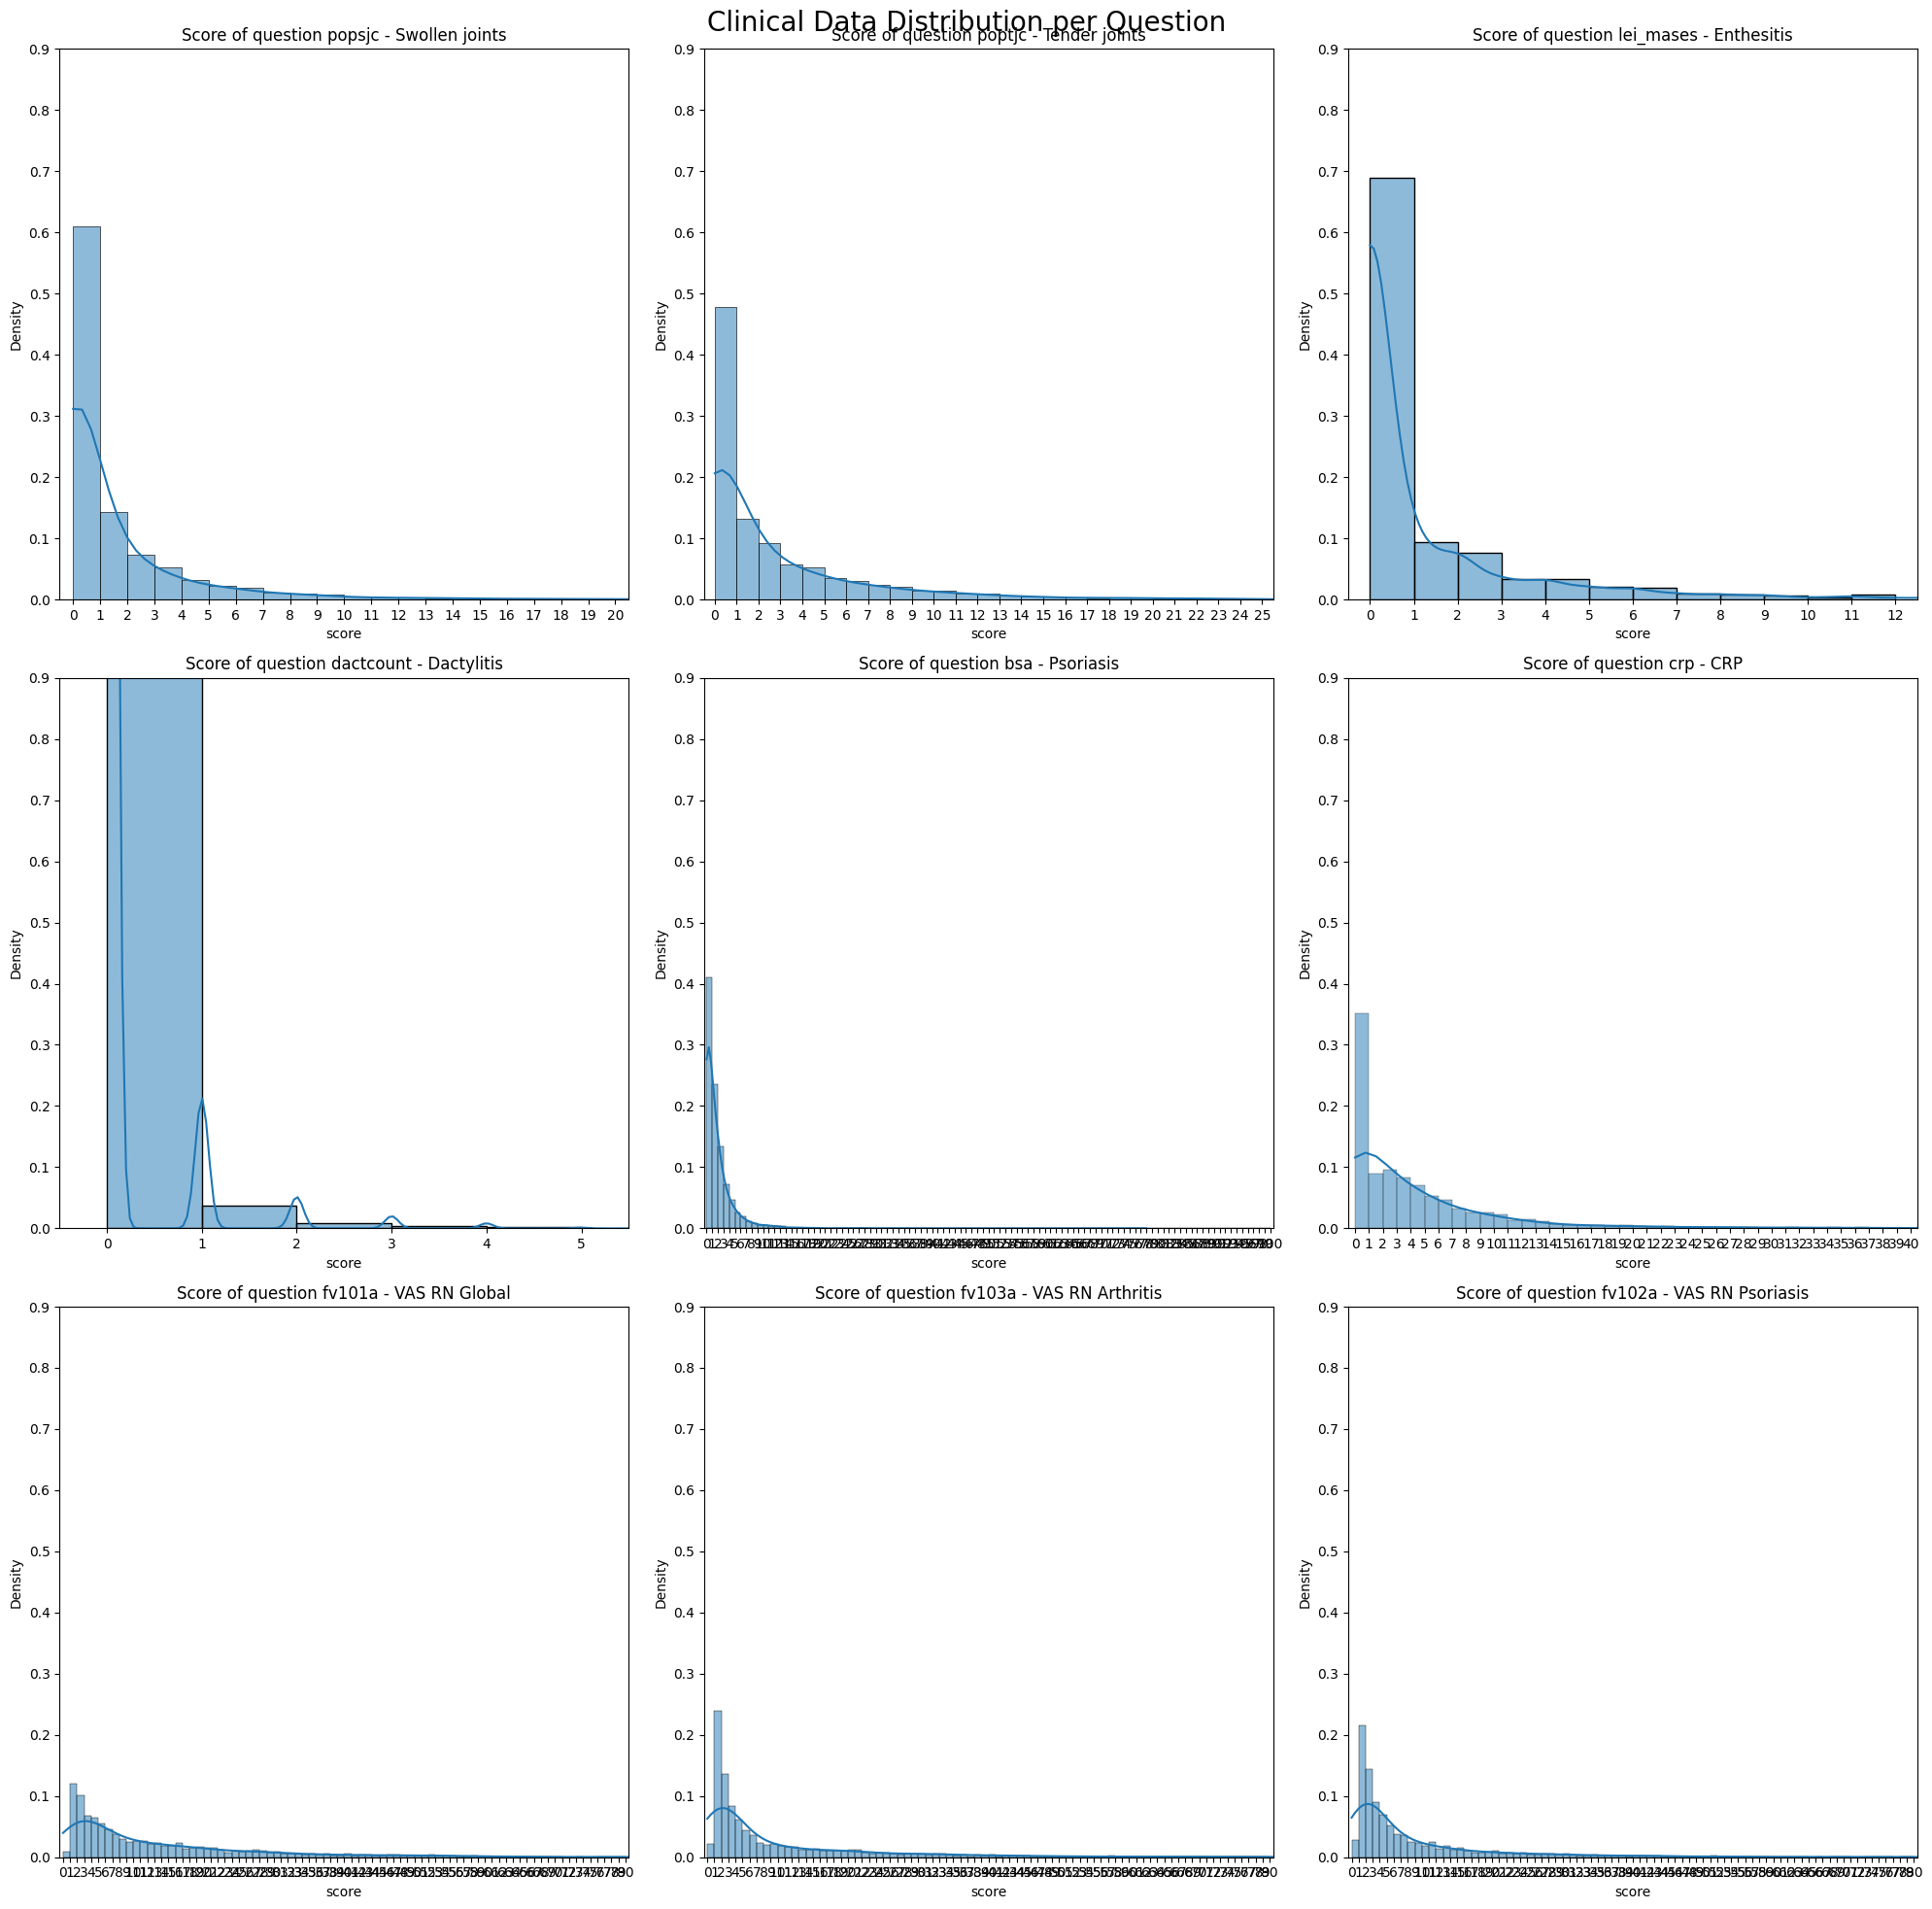

In [38]:
plot_histograms_byclinicalvars(clinical_data, clinical_variables, clinical_vars_dict, clinical_vars_ylim, 'Clinical Data Distribution per Question')

In [39]:
clinical_data['dactcount'].value_counts().sort_index()

dactcount
0    4556
1     182
2      44
3      17
4       7
5       1
6       1
8       1
Name: count, dtype: Int64

#### Merge 

In [40]:
## Merge Demographics
data_complete  = psaid12.merge(demographic_data, left_on=['respondentid'], right_on=['respondentid'], how='left')

## Merge Clinical Variables
data_complete = data_complete.merge(clinical_data, left_on=['respondentid','mm'], right_on=['respondentid','mm'], how='left')
data_complete.sort_values(['respondentid', 'mm']).head()

## Check Merged Dataset
print(f'data1: {psaid12.shape}, data2:{clinical_data.shape}, merged:{data_complete.shape}')
#data23.head(1)        #Review content
clinical_data.info()         #Check data types and missing values


data1: (5099, 16), data2:(5099, 21), merged:(5099, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5099 entries, 0 to 5098
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   respondentid  5099 non-null   Int64  
 1   mm            5099 non-null   int64  
 2   bmi           2653 non-null   float32
 3   packyear      4706 non-null   float32
 4   pm86b         5043 non-null   float32
 5   popsjc        4848 non-null   Int64  
 6   poptjc        4848 non-null   Int64  
 7   lei_mases     4798 non-null   Int64  
 8   dactcount     4809 non-null   Int64  
 9   bsa           4492 non-null   float32
 10  crp           4042 non-null   float32
 11  fv101a        4736 non-null   Int64  
 12  fv103a        4736 non-null   Int64  
 13  fv102a        4736 non-null   Int64  
 14  dapsa         3722 non-null   float32
 15  dapsa_state   3722 non-null   Int64  
 16  pasdas        3090 non-null   float32
 17  pasdas_state  30

### Save Formatted Dataset

In [41]:
folder_path = "/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_Pre-Processing & Inspection"
file_name = "PsAID_Preprocessed"

# Ensure the folder exists
os.makedirs(folder_path, exist_ok=True)

# Save
data_complete.to_csv(f'{folder_path}/{file_name}.csv', index=False)
print(f' Dataset saved to {folder_path}/{file_name}.csv')

 Dataset saved to /Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_Pre-Processing & Inspection/PsAID_Preprocessed.csv


## Statistics Table

#### Health Status Characteristics of all datapoint

In [42]:
def descriptive_stats(df, categorical_override=None):
    desc = []
    print(df.head())

    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]) and col not in categorical_override:
            # Continuous variable
            if col == 'bmi':
                df_subset = df[df['mm'] %12 == 0] # BMI is collected yearly. Select rows where mm is divisible by 12.
                print(len(df_subset))
                median = df[col].median()
                q1 = df[col].quantile(0.25)
                q3 = df[col].quantile(0.75)
                iqr = q3 - q1
                desc.append({
                    'Variable': col,
                    'Type': 'Continuous',
                    'Statistic': f'{median:.2f} (IQR {q1:.2f}-{q3:.2f})',
                    '# Missings': f'{df_subset[col].isna().sum()} ({round((df_subset[col].isna().sum())/len(df_subset)*100, 1)}%)'
                })

            else:
                median = df[col].median()
                q1 = df[col].quantile(0.25)
                q3 = df[col].quantile(0.75)
                iqr = q3 - q1
                desc.append({
                    'Variable': col,
                    'Type': 'Continuous',
                    'Statistic': f'{median:.2f} (IQR {q1:.2f}-{q3:.2f})',
                    '# Missings': f'{df[col].isna().sum()} ({round((df[col].isna().sum())/5099*100, 2)}%)'
                })
        else:
            # Categorical variable
            value_counts = df[col].value_counts(dropna=False)
            for category, count in value_counts.items():
                percent = (count/len(df[col])) * 100
                desc.append({
                    'Variable': f'{col} = {category}',
                    'Type': 'Categorical',
                    'Statistic': f' {count} ({percent:.1f}%)',
                    '# Missings': ' '
                })

    return pd.DataFrame(desc)

In [63]:
states_dict

{'dapsa_state': {0: 'Remission', 1: 'Low', 2: 'Moderate', 3: 'High'},
 'pasdas_state': {0: 'Remission', 1: 'Low', 2: 'Moderate', 3: 'High'},
 'mda_state': {0: 'VLDA', 1: 'MDA', 2: 'No MDA'},
 'psaid_state': {0: 'Remission', 1: 'Low', 2: 'Moderate', 3: 'High'},
 'pass_state': {0: 'PASS', 1: 'No PASS'}}

In [44]:
descriptive_stats(data_complete[['mm'] + demographic_variables + clinical_variables + composite_scores + disease_states], categorical_override=disease_states)

   mm Geslacht  age        bmi   packyear      pm86b  popsjc  poptjc  \
0  36        M   50  21.222809   0.000000  15.112936       0       3   
1   6        M   43        NaN   9.473684   1.379877    <NA>    <NA>   
2  18        M   30        NaN   0.736842  50.496922       0       3   
3  18        F   36        NaN  15.789474  15.474333       0       2   
4  84        M   54  24.835646  16.000000  11.630390       0       0   

   lei_mases  dactcount  ...  fv103a  fv102a  dapsa    pasdas  psaid12  \
0          2          0  ...       4       3    NaN       NaN     1.20   
1       <NA>       <NA>  ...    <NA>    <NA>    NaN       NaN     1.55   
2          1          0  ...       3      10   13.0  3.430997     5.70   
3          0          0  ...       1       3    NaN       NaN     0.95   
4          0          0  ...       2       2   10.1  1.189626     0.00   

   dapsa_state  pasdas_state  mda_state  psaid_state  pass_state  
0         <NA>          <NA>          2            1   

,Variable,Type,Statistic,# Missings
0,mm,Continuous,12.00 (IQR 6.00-24.00),0 (0.0%)
1,Geslacht = F,Categorical,2575 (50.5%),
2,Geslacht = M,Categorical,2519 (49.4%),
3,Geslacht = nan,Categorical,5 (0.1%),
4,age,Continuous,52.00 (IQR 41.00-61.00),5 (0.1%)
5,bmi,Continuous,27.77 (IQR 24.68-31.53),244 (8.4%)
6,packyear,Continuous,5.53 (IQR 0.00-18.42),393 (7.71%)
7,pm86b,Continuous,8.97 (IQR 3.45-30.95),56 (1.1%)
8,popsjc,Continuous,0.00 (IQR 0.00-2.00),251 (4.92%)
9,poptjc,Continuous,1.00 (IQR 0.00-3.00),251 (4.92%)


In [45]:
demographic_variables = ['Geslacht', 'age', 'bmi', 'packyear', 'pm86b']
clinical_variables = ['popsjc', 'poptjc', 'lei_mases', 'dactcount', 'bsa', 'crp', 'fv101a', 'fv103a', 'fv102a']
disease_states = ['dapsa_state', 'pasdas_state', 'mda_state', 'psaid_state' ] 
composite_scores = ['dapsa', 'pasdas', 'psaid12'] 

In [108]:
# Ensure the folder exists
os.makedirs('data_storage', exist_ok=True)

# Function to compute median [Q1, Q3]
def median_iqr(series):
    q1 = series.quantile(0.25)
    median = series.quantile(0.5)
    q3 = series.quantile(0.75)
    return f"{median:.2f} [{q1:.2f}, {q3:.2f}]"

# Counts per group (once)
counts = data_complete.groupby('mm').size().rename('n')

# Median [Q1, Q3] for domains
medians_iqr_domains = data_complete.groupby('mm')[clinical_variables + composite_scores].agg(median_iqr)

# Combine counts, domain medians, and total score
summary_table = pd.concat([counts, medians_iqr_domains], axis=1)

# Save to Excel
#summary_table.to_excel('data_storage/clinicalVars_summary.xlsx', index=True)

print("Summary table saved to data_storage/psaid12_summary.xlsx")
summary_table

Summary table saved to data_storage/psaid12_summary.xlsx


,n,popsjc,poptjc,lei_mases,dactcount,bsa,crp,fv101a,fv103a,fv102a,dapsa,pasdas,psaid12
mm,,,,,,,,,,,,,
0,606,"2.00 [1.00, 5.00]","4.00 [1.00, 8.00]","0.00 [0.00, 2.00]","0.00 [0.00, 0.00]","2.00 [1.00, 4.00]","4.05 [0.73, 12.00]","25.00 [12.00, 42.00]","19.00 [6.00, 36.00]","12.00 [3.00, 28.00]","17.95 [11.73, 25.38]","4.34 [3.49, 5.13]","3.60 [2.10, 5.60]"
3,557,"1.00 [0.00, 2.00]","2.00 [0.00, 4.00]","0.00 [0.00, 2.00]","0.00 [0.00, 0.00]","1.00 [0.00, 3.00]","2.80 [0.00, 7.00]","12.00 [5.00, 22.00]","7.00 [2.00, 18.25]","5.00 [2.00, 13.00]","10.60 [5.80, 17.35]","3.43 [2.57, 4.20]","2.80 [1.05, 4.70]"
6,563,"0.00 [0.00, 2.00]","1.00 [0.00, 4.00]","0.00 [0.00, 1.00]","0.00 [0.00, 0.00]","1.00 [0.00, 2.00]","2.00 [0.00, 6.00]","8.00 [3.00, 19.00]","5.00 [2.00, 13.00]","4.00 [2.00, 10.00]","9.40 [4.40, 15.70]","3.11 [2.25, 3.93]","2.35 [0.80, 4.50]"
9,532,"0.00 [0.00, 1.00]","1.00 [0.00, 3.00]","0.00 [0.00, 1.00]","0.00 [0.00, 0.00]","1.00 [0.00, 2.50]","2.00 [0.00, 5.00]","7.00 [3.00, 18.00]","4.00 [1.00, 11.00]","4.00 [1.00, 10.00]","8.40 [3.62, 14.90]","2.92 [1.95, 3.77]","2.15 [0.74, 4.11]"
12,521,"0.00 [0.00, 1.00]","0.00 [0.00, 3.00]","0.00 [0.00, 1.00]","0.00 [0.00, 0.00]","1.00 [0.00, 2.00]","2.00 [0.00, 5.00]","6.00 [2.00, 16.00]","3.00 [1.00, 9.00]","3.00 [1.00, 9.00]","7.40 [3.20, 14.50]","2.68 [1.87, 3.82]","1.95 [0.70, 4.10]"
18,550,"0.00 [0.00, 1.00]","0.00 [0.00, 2.00]","0.00 [0.00, 1.00]","0.00 [0.00, 0.00]","1.00 [0.00, 2.00]","2.00 [0.00, 5.00]","6.00 [2.00, 14.00]","3.00 [1.00, 9.00]","3.00 [1.00, 8.00]","8.40 [3.40, 15.26]","2.78 [1.84, 3.79]","1.88 [0.60, 4.34]"
24,498,"0.00 [0.00, 1.00]","0.00 [0.00, 2.00]","0.00 [0.00, 1.00]","0.00 [0.00, 0.00]","1.00 [0.00, 2.00]","2.00 [0.00, 5.00]","6.00 [2.00, 13.00]","3.00 [1.00, 8.00]","3.00 [1.00, 9.00]","7.00 [2.60, 13.35]","2.59 [1.75, 3.54]","1.85 [0.55, 4.04]"
36,443,"0.00 [0.00, 1.00]","0.00 [0.00, 2.00]","0.00 [0.00, 1.00]","0.00 [0.00, 0.00]","1.00 [0.00, 2.00]","2.00 [0.00, 5.00]","5.00 [2.00, 13.00]","2.00 [1.00, 7.00]","3.00 [1.00, 8.00]","6.30 [2.75, 13.15]","2.61 [1.64, 3.63]","1.55 [0.50, 3.75]"
48,327,"0.00 [0.00, 1.00]","0.00 [0.00, 2.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","1.00 [0.00, 2.00]","1.20 [0.00, 5.00]","4.00 [2.00, 11.00]","2.00 [1.00, 5.00]","3.00 [1.00, 6.50]","6.80 [3.00, 12.30]","2.42 [1.75, 3.36]","1.55 [0.50, 3.52]"


In [131]:
#'mda_state': {0: 'VLDA', 1: 'MDA', 2: 'No MDA'}, 
MDA_counts = data_complete.groupby('mm')['mda_state'].value_counts(dropna=False).unstack()
MDA_counts = MDA_counts.rename(columns={pd.NA: '#missing'})
MDA_counts['p_remission'] = round(((MDA_counts[0] + MDA_counts[1])/(MDA_counts[0] + MDA_counts[1]+ MDA_counts[2]))*100)
MDA_counts['Missingness'] = round((MDA_counts['#missing'] / counts)*100)

MDA_counts

mda_state,0,1,2,#missing,p_remission,Missingness
mm,,,,,,
0,7,75,501,23,14.0,4.0
3,40,110,330,77,31.0,14.0
6,58,118,272,115,39.0,20.0
9,77,115,247,93,44.0,17.0
12,81,123,227,90,47.0,17.0
18,101,148,241,60,51.0,11.0
24,116,136,190,56,57.0,11.0
36,91,122,159,71,57.0,16.0
48,55,99,124,49,55.0,15.0


In [134]:
(MDA_counts[0] + MDA_counts[1]).sum()

1921

In [117]:
# % missing per clinical variable per timepoint
cols = clinical_variables + composite_scores

def n_pct_missing(s):
    n = s.isna().sum()
    pct = s.isna().mean() * 100
    return f"{n} ({pct:.1f})"

missing_np = (
    data_complete.groupby('mm')[cols]
    .agg(n_pct_missing)
    .add_suffix('_miss')
)
file_name = 'ClinicalVars_Missingness'
missing_np.to_csv(f'{folder_path}/{file_name}.csv', index=False)
print(f' Dataset saved to {folder_path}/{file_name}.csv')

 Dataset saved to /Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_Pre-Processing & Inspection/ClinicalVars_Missingness.csv


#### Participant Characteristics at baseline

In [46]:
print(f' # Participants: {data_complete['respondentid'].nunique()}')

## Follow up time in DEPAR
max_mm_per_respondent = data_complete.groupby('respondentid')['mm'].max()
print(f' Median max follow-up time: {max_mm_per_respondent.median()}, IQR [{max_mm_per_respondent.quantile(0.25)}, {max_mm_per_respondent.quantile(0.75)}]')

 # Participants: 880
 Median max follow-up time: 36.0, IQR [12.0, 60.0]


In [47]:
def participant_characteristics(data, var, TYPE):
    ## Age from Participants at baseline
    # Step 1: Sort by respondent_id and mm
    data_sorted = data.sort_values(by=['respondentid', 'mm'])
    
    # Step 2: Drop rows with missing var
    data_no_na = data_sorted.dropna(subset=[var])
    
    # Step 3: Select the first available var per respondent
    first_per_respondent = data_no_na.groupby('respondentid')[var].first()
    
    # Step 4: Check missings
    no_ids = data.groupby('respondentid')[var].apply(lambda x: x.isna().all()) # Group by respondent and check if all var values are missing
    respondents_without = no_ids[no_ids].index.tolist() # Filter only those with all ages missing

    if TYPE == 'continuous': 
        # Step 4: Compute median and IQR
        median = first_per_respondent.median()
        q1 = first_per_respondent.quantile(0.25)
        q3 = first_per_respondent.quantile(0.75)
        iqr = q3 - q1
        
        # Step 5: Print results
        print(f"Median first available {var}: {median:.2f}")
        print(f"IQR: {iqr:.2f} (Q1: {q1:.2f}, Q3: {q3:.2f})")
        print(f"Number of respondents with no {var} data: {len(respondents_without)}")
    elif TYPE == 'category': 
        # Step 4: Compute %
        per_respondent_count = first_per_respondent.value_counts()
        per_respondent_percentage = first_per_respondent.value_counts(normalize=True) * 100
        
        # # Step 5: Print results
        print(f' Numbers: {per_respondent_count}')
        print(f' percentages: {per_respondent_percentage}')
        print(f"Number of respondents with no gender data: {len(respondents_without)}")
    

In [48]:
## Age
participant_characteristics(data_complete, 'age', 'continuous')

Median first available age: 51.00
IQR: 20.75 (Q1: 40.00, Q3: 60.75)
Number of respondents with no age data: 2


In [49]:
## BMI
participant_characteristics(data_complete, 'bmi', 'continuous')

Median first available bmi: 27.77
IQR: 6.90 (Q1: 24.67, Q3: 31.56)
Number of respondents with no bmi data: 36


In [50]:
36/880*100

4.090909090909091

In [51]:
## GENDER
participant_characteristics(data_complete, 'Geslacht', 'category')
Missing_Gender = data_complete[data_complete['Geslacht'].isna()][['respondentid', 'mm', 'Geslacht']]
Missing_Gender['respondentid'].unique()

 Numbers: Geslacht
F    443
M    435
Name: count, dtype: int64
 percentages: Geslacht
F    50.455581
M    49.544419
Name: proportion, dtype: float64
Number of respondents with no gender data: 2


array([36415158, 52913581])

In [52]:
## Symptom duration prior to diagnosis
participant_characteristics(data_complete, 'pm86b', 'continuous')
# pm86_per_respondent = data_complete[data_complete['mm'] == 0]['pm86b']
# print(f' Median: {pm86_per_respondent.median()}, IQR [{pm86_per_respondent.quantile(0.25)}, {pm86_per_respondent.quantile(0.75)}]')

Median first available pm86b: 9.30
IQR: 28.25 (Q1: 3.42, Q3: 31.67)
Number of respondents with no pm86b data: 15


## Check Data Scaling Options

#### Distributions of Scaled Data by Domain

Starting data scaling...
Data scaling done in 0.01 seconds.
 min: -2.0
 max: 11.0
 gp01: min, -1.5 max, 2.5
2.65
 gp02: min, -1.5 max, 2.5
2.65
 gp03: min, -1.5 max, 3.5
3.65
 gp04: min, -1.5 max, 2.5
2.65
 gp05: min, -1.5 max, 2.5
2.65
 gp06: min, -1.5 max, 2.5
2.65
 gp07: min, -1.5 max, 2.5
2.65
 gp08: min, -1.5 max, 3.5
3.65
 gp09: min, -1.5 max, 3.5
3.65
 gp10: min, -0.5 max, 10.5
10.55
 gp11: min, -0.5 max, 4.5
4.55
 gp12: min, -0.5 max, 5.5
5.55


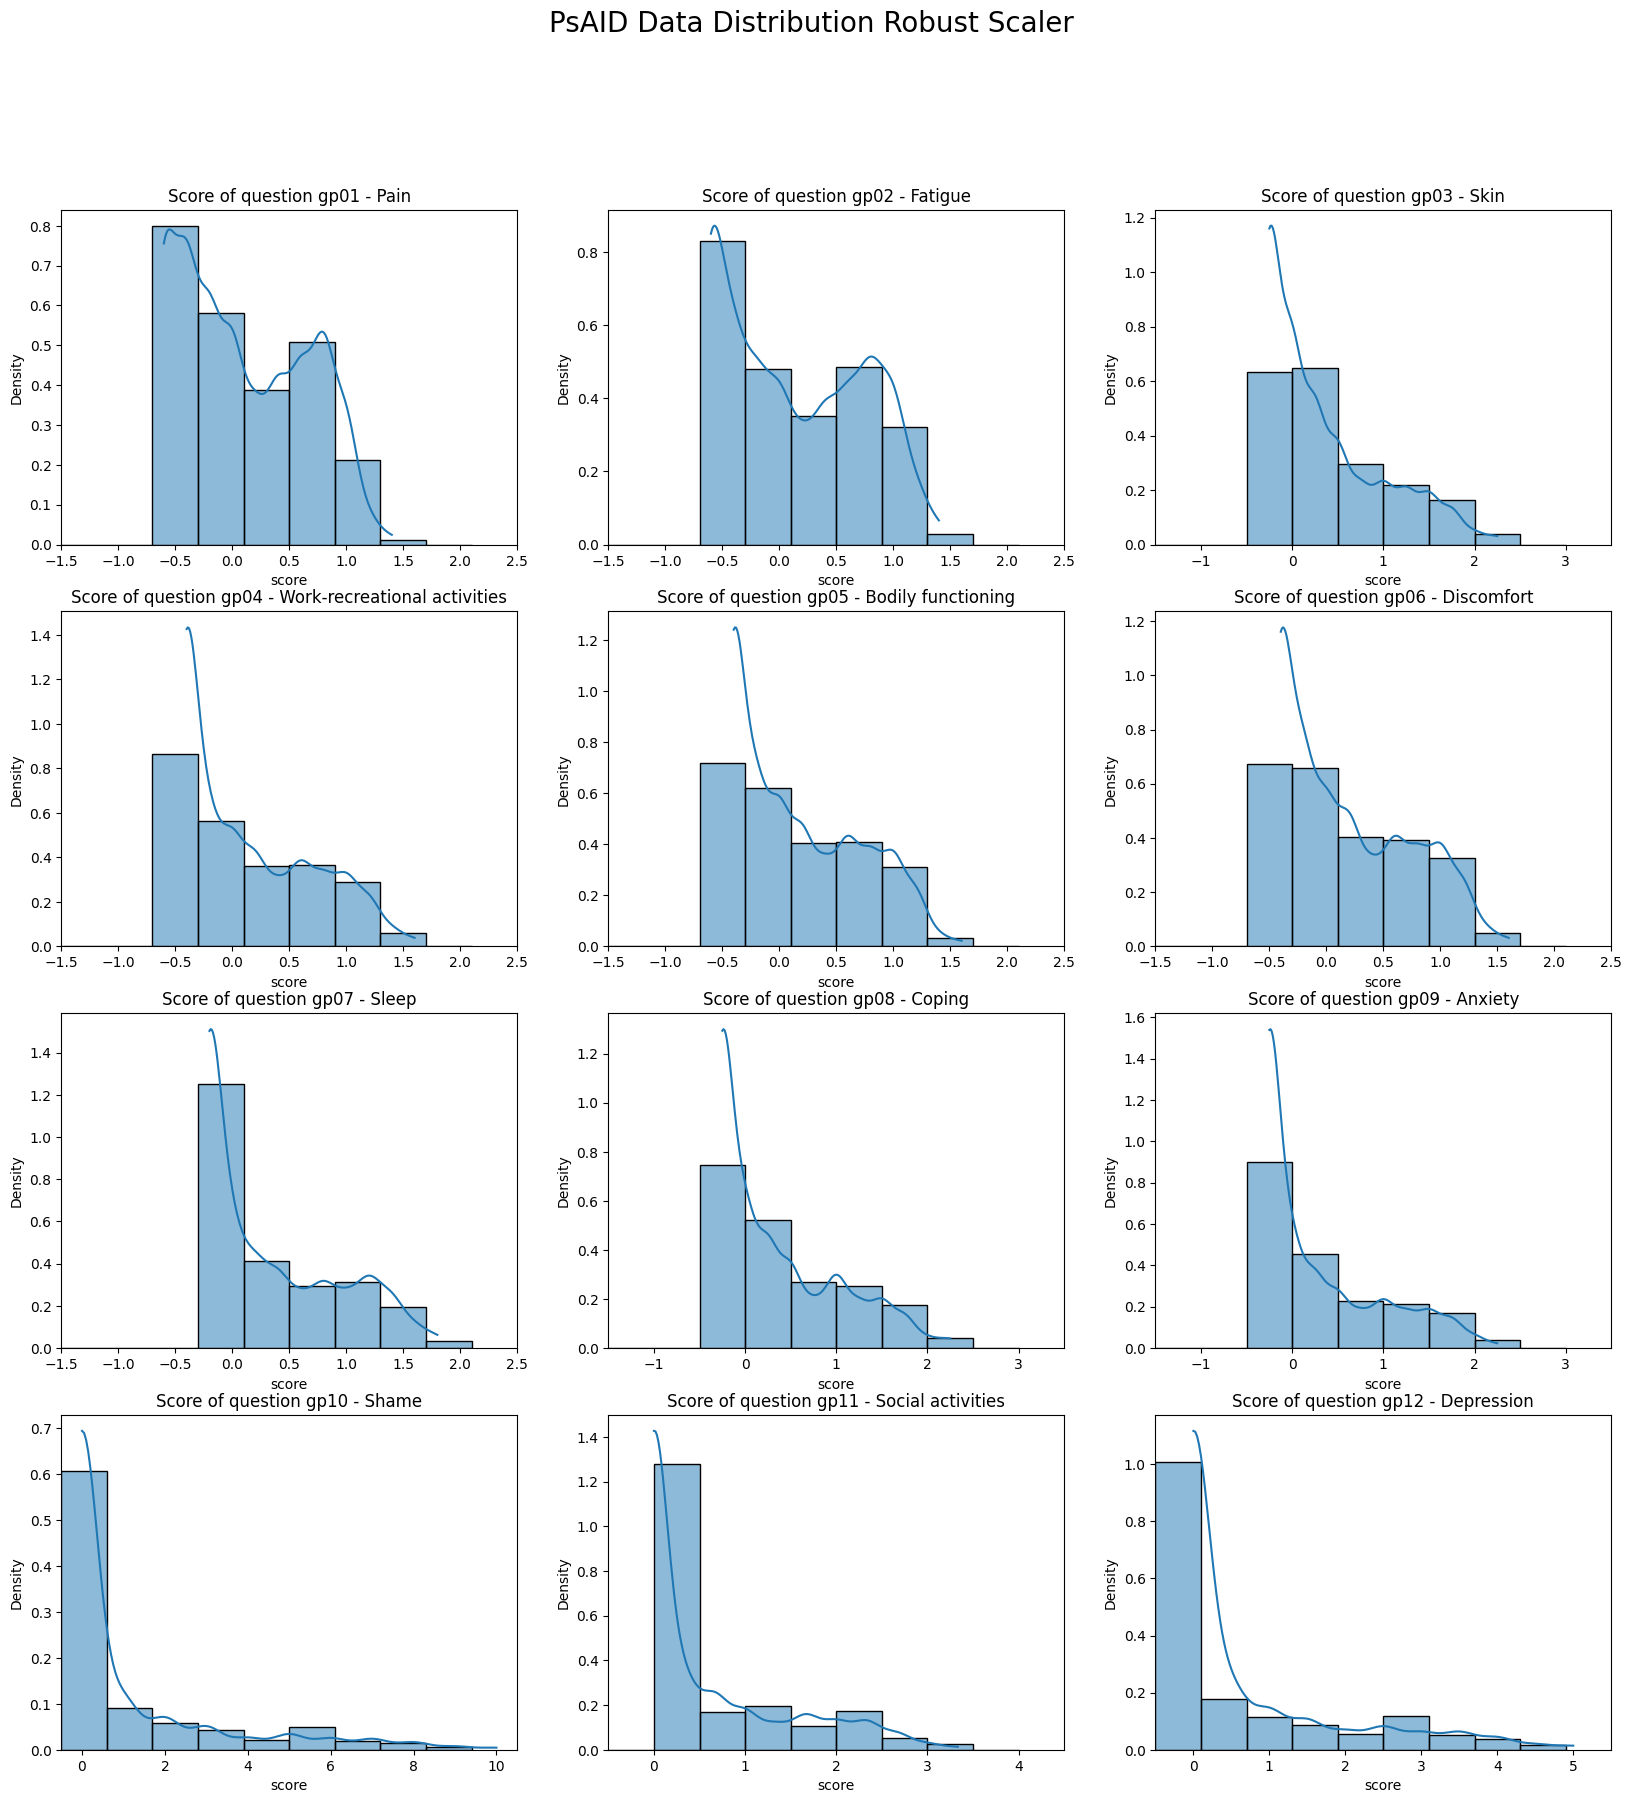

In [53]:
## Data Scaling
import time
from sklearn.preprocessing import StandardScaler, RobustScaler

print("Starting data scaling...")
start = time.time()
scaler = RobustScaler()
data_RobustScaled = pd.DataFrame(
    scaler.fit_transform(psaid12[columns_gp]),      # Only values are transformed
    columns=columns_gp,            # Keep original column names
    index=psaid12[columns_gp].index                 # Optional: keep original index
)

end = time.time()
print(f"Data scaling done in {end - start:.2f} seconds.")

print(f' min: {np.copysign(math.ceil(np.abs(data_RobustScaled.min().min())), data_RobustScaled.min().min())-1}')
print(f' max: {np.copysign(math.ceil(np.abs(data_RobustScaled.max().max())), data_RobustScaled.max().max())+1}')

plot_histograms_byvars(data_RobustScaled, columns_gp, domains_dict, 'PsAID Data Distribution Robust Scaler')

Starting data scaling...
Data scaling done in 0.00 seconds.
 gp01: min, -2.5 max, 3.5
3.75
 gp02: min, -2.5 max, 3.5
3.75
 gp03: min, -1.5 max, 4.5
4.65
 gp04: min, -1.5 max, 3.5
3.65
 gp05: min, -2.5 max, 3.5
3.75
 gp06: min, -2.5 max, 3.5
3.75
 gp07: min, -1.5 max, 3.5
3.65
 gp08: min, -1.5 max, 3.5
3.65
 gp09: min, -1.5 max, 3.5
3.65
 gp10: min, -1.5 max, 5.5
5.65
 gp11: min, -1.5 max, 4.5
4.65
 gp12: min, -1.5 max, 4.5
4.65


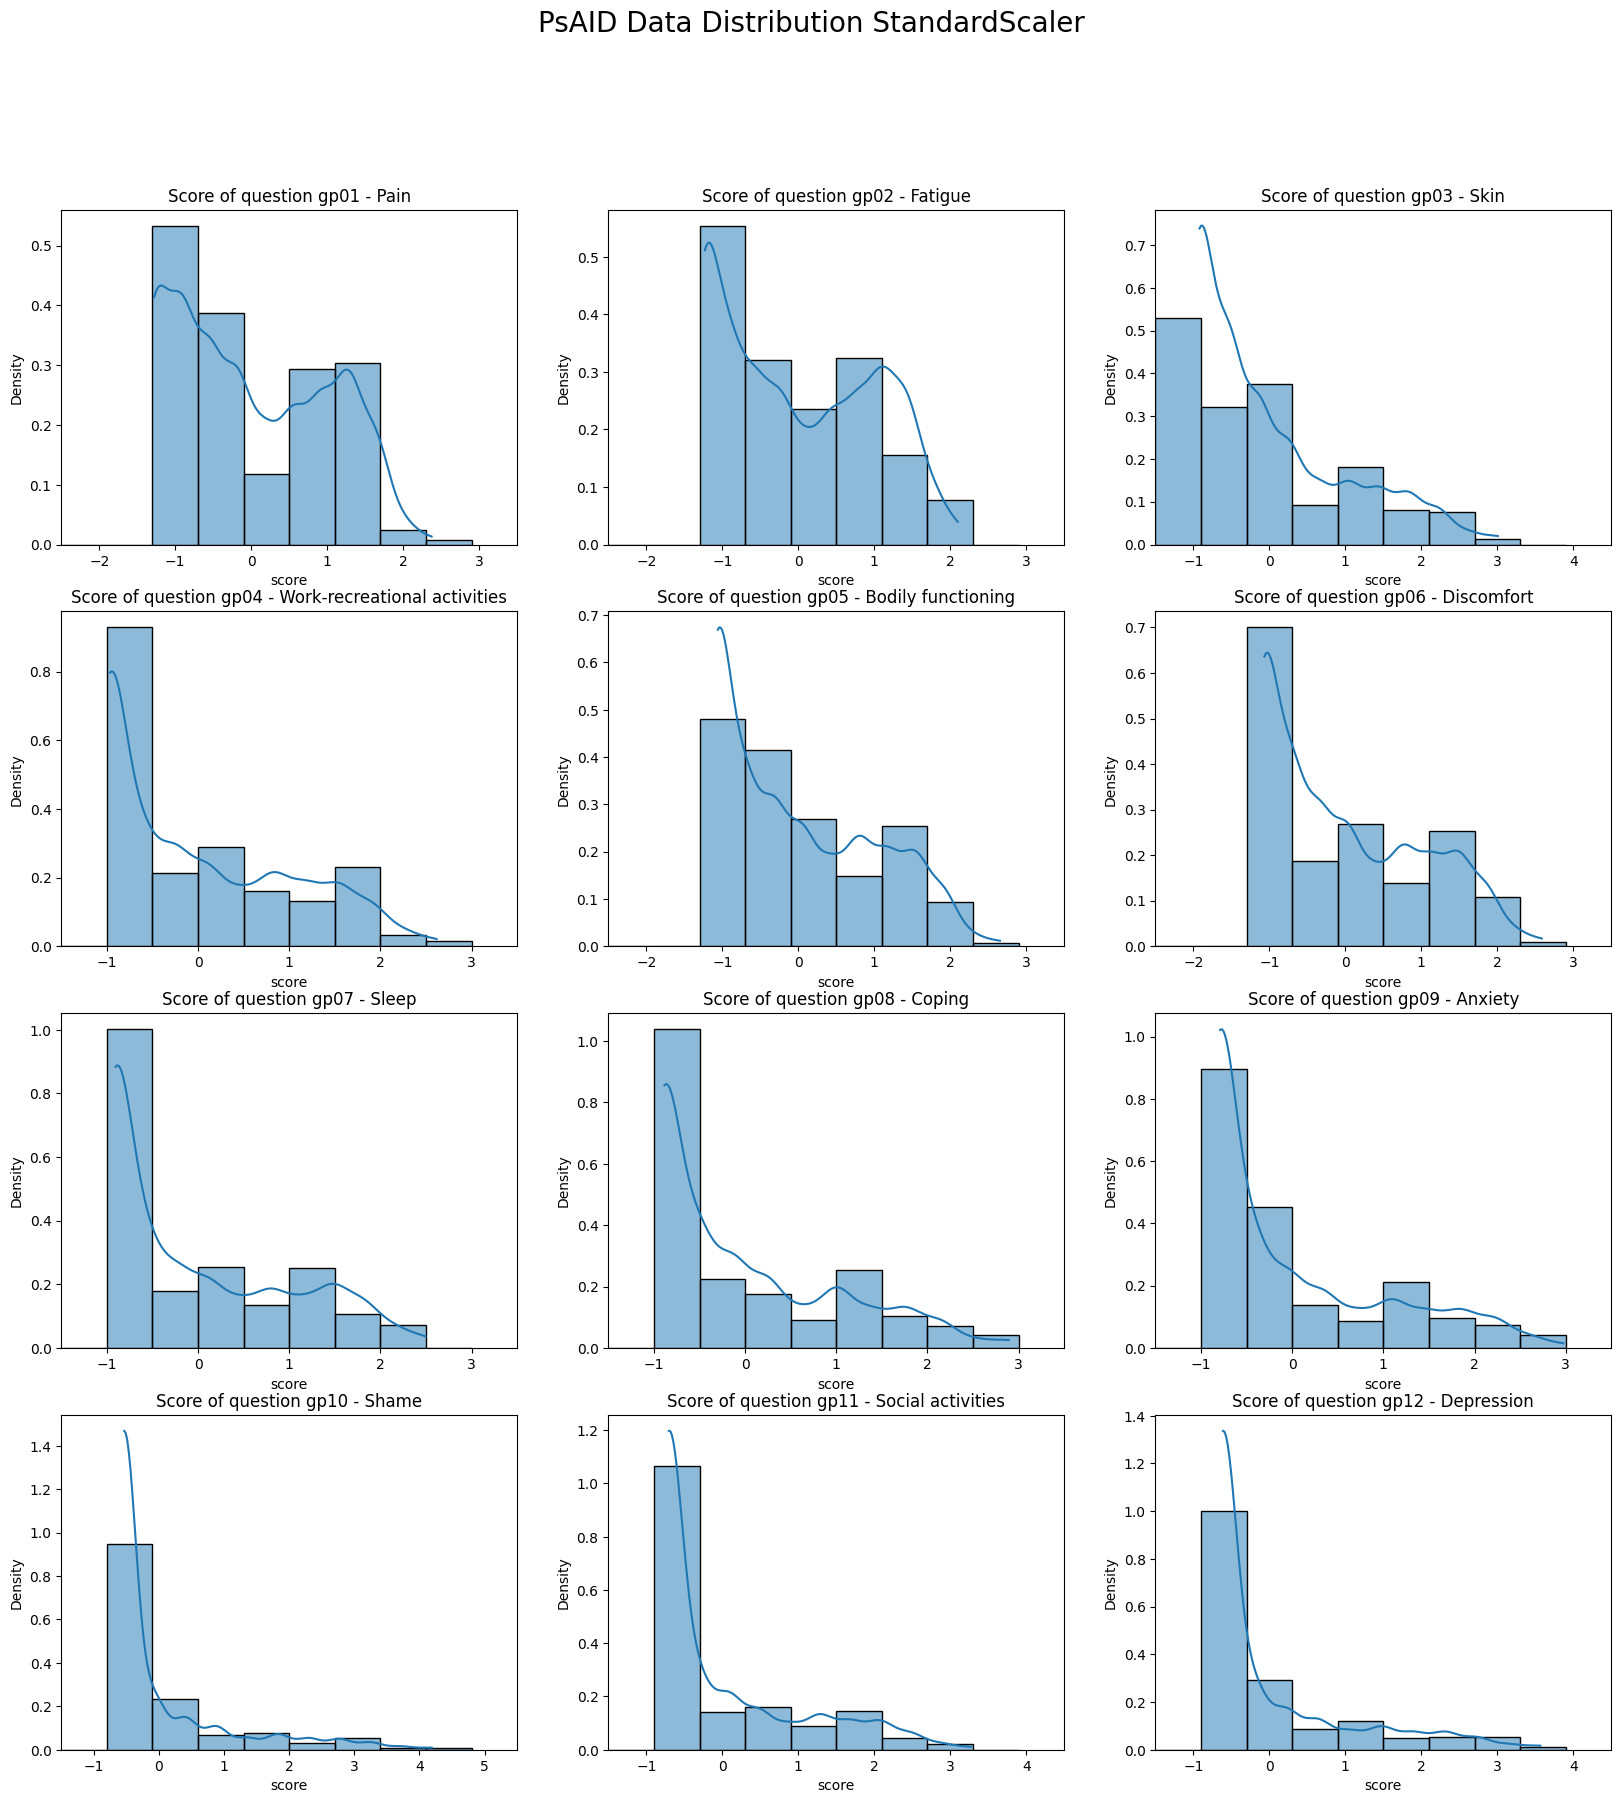

In [54]:
print("Starting data scaling...")
start = time.time()
scaler = StandardScaler()
data_StandardScaled = pd.DataFrame(
    scaler.fit_transform(psaid12[columns_gp]),      # Only values are transformed
    columns=columns_gp,            # Keep original column names
    index=psaid12[columns_gp].index                 # Optional: keep original index
)

end = time.time()
print(f"Data scaling done in {end - start:.2f} seconds.")

plot_histograms_byvars(data_StandardScaled, columns_gp, domains_dict, 'PsAID Data Distribution StandardScaler')

In [55]:
print('psaid12')
desc = psaid12[columns_gp].describe().T  # Transpose for readability
desc['median'] = psaid12.median()
desc['IQR'] = psaid12.quantile(0.75) - psaid12.quantile(0.25)
summary = desc[['mean', 'std', 'median', 'IQR', 'min', 'max']]
summary

psaid12


,mean,std,median,IQR,min,max
gp01,3.498725,2.739678,3.0,5.0,0.0,10.0
gp02,3.693665,3.006385,3.0,5.0,0.0,10.0
gp03,2.342028,2.546912,1.0,4.0,0.0,10.0
gp04,2.696019,2.792231,2.0,5.0,0.0,10.0
gp05,2.851736,2.693945,2.0,5.0,0.0,10.0
gp06,2.918611,2.739623,2.0,5.0,0.0,10.0
gp07,2.660522,2.940543,1.0,5.0,0.0,10.0
gp08,2.341439,2.647180,1.0,4.0,0.0,10.0
gp09,2.100020,2.655704,1.0,4.0,0.0,10.0
gp10,1.132183,2.117799,0.0,1.0,0.0,10.0


In [56]:
print('psaid12 StandardScaled')
print(f'data range: {np.copysign(math.ceil(np.abs(data_StandardScaled.min().min())), data_StandardScaled.min().min())}, {np.copysign(math.ceil(np.abs(data_StandardScaled.max().max())), data_StandardScaled.max().max())}')
desc = data_StandardScaled.describe().T  # Transpose for readability
desc['median'] = data_StandardScaled.median()
desc['IQR'] = data_StandardScaled.quantile(0.75) - data_StandardScaled.quantile(0.25)
summary = desc[['mean', 'std', 'median', 'IQR', 'min', 'max']]
summary

psaid12 StandardScaled
data range: -2.0, 5.0


,mean,std,median,IQR,min,max
gp01,6.828122e-17,1.000098,-0.182056,1.825211,-1.277182,2.373240
gp02,6.967471e-17,1.000098,-0.230753,1.663290,-1.228728,2.097853
gp03,-5.573977e-17,1.000098,-0.526975,1.570683,-0.919646,3.007062
gp04,-6.967471e-19,1.000098,-0.249294,1.790858,-0.965638,2.616079
gp05,-1.672193e-17,1.000098,-0.316198,1.856196,-1.058676,2.653716
gp06,2.786989e-17,1.000098,-0.335339,1.825247,-1.065438,2.585057
gp07,2.647639e-17,1.000098,-0.564754,1.700533,-0.904861,2.496205
gp08,-3.274712e-17,1.000098,-0.506793,1.511190,-0.884590,2.893385
gp09,-5.399790e-17,1.000098,-0.414251,1.506340,-0.790836,2.975013
gp10,3.483736e-18,1.000098,-0.534656,0.472235,-0.534656,4.187690


In [57]:
print('psaid12 RobustScaled')
print(f'data range: {np.copysign(math.ceil(np.abs(data_RobustScaled.min().min())), data_RobustScaled.min().min())}, {np.copysign(math.ceil(np.abs(data_RobustScaled.max().max())), data_RobustScaled.max().max())}')
desc = data_RobustScaled.describe().T  # Transpose for readability
desc['median'] = data_RobustScaled.median()
desc['IQR'] = data_RobustScaled.quantile(0.75) - data_RobustScaled.quantile(0.25)
summary = desc[['mean', 'std', 'median', 'IQR', 'min', 'max']]
summary

psaid12 RobustScaled
data range: -1.0, 10.0


,mean,std,median,IQR,min,max
gp01,0.099745,0.547936,0.0,1.0,-0.60,1.400000
gp02,0.138733,0.601277,0.0,1.0,-0.60,1.400000
gp03,0.335507,0.636728,0.0,1.0,-0.25,2.250000
gp04,0.139204,0.558446,0.0,1.0,-0.40,1.600000
gp05,0.170347,0.538789,0.0,1.0,-0.40,1.600000
gp06,0.183722,0.547925,0.0,1.0,-0.40,1.600000
gp07,0.332104,0.588109,0.0,1.0,-0.20,1.800000
gp08,0.335360,0.661795,0.0,1.0,-0.25,2.250000
gp09,0.275005,0.663926,0.0,1.0,-0.25,2.250000
gp10,1.132183,2.117799,0.0,1.0,0.00,10.000000


#### tSNE

In [58]:
## Compute t-SNE 2D with PSAID columns
def tSNE_2D(data, columns_gp, RandomSeed):
    tsne2D = pd.DataFrame(TSNE(n_components=2, random_state=RandomSeed).fit_transform(data[columns_gp]), columns=['tSNE1', 'tSNE2'])

     ## Plot t-SNE Visualisation
    plt.figure(figsize=(8, 6))
    plt.scatter(tsne2D['tSNE1'], tsne2D['tSNE2'])
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title(f'2D t-SNE Visualization')
    plt.show()

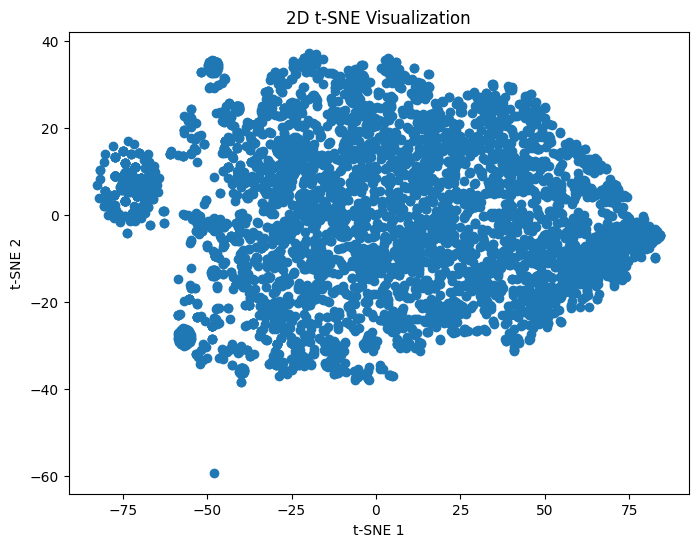

In [59]:
# Raw Data
tSNE_2D(psaid12, columns_gp, RandomSeed)

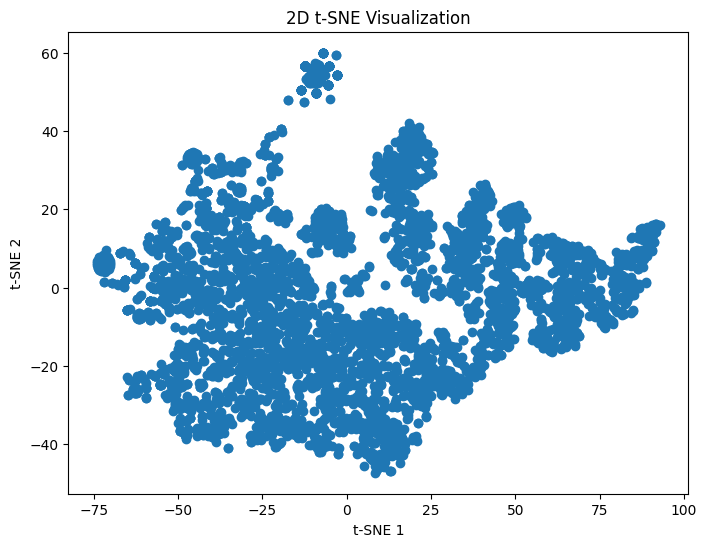

In [60]:
# Robust Scaled data
tSNE_2D(data_RobustScaled, columns_gp, RandomSeed)

In [61]:
Included_PID = pd.DataFrame(psaid12['respondentid'].unique())
Included_PID.to_csv(f'{folder_path}/{'included_respondentIDs'}.csv', index=False)
print(f' Dataset saved to {folder_path}/{file_name}.csv')

 Dataset saved to /Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_Pre-Processing & Inspection/PsAID_Preprocessed.csv
